In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/train.csv')


In [4]:
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  1458644
No. of columns:  11


In [5]:
# Dividir en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


In [6]:
print("No. de filas en el conjunto de entrenamiento:", train_df.shape[0])
print("No. de columnas en el conjunto de entrenamiento:", train_df.shape[1])


No. de filas en el conjunto de entrenamiento: 1166915
No. de columnas en el conjunto de entrenamiento: 11


In [7]:
train_df = train_df.reset_index(drop=True)
#Mantener secuencia en los indices

In [8]:
train_df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id0458976,2,2016-06-29 18:21:02,2016-06-29 18:39:55,1,-73.862762,40.768822,-73.891701,40.746689,N,1133
1,id0434613,2,2016-04-25 13:03:26,2016-04-25 13:18:13,1,-73.958038,40.783237,-73.975510,40.760853,N,887
2,id3809234,2,2016-05-07 12:36:09,2016-05-07 12:47:35,1,-73.969460,40.785519,-73.989243,40.771748,N,686
3,id1203705,1,2016-05-14 18:44:17,2016-05-14 18:57:55,1,-73.981743,40.736549,-73.998352,40.726440,N,818
4,id1896645,2,2016-04-10 22:51:25,2016-04-10 23:07:16,1,-73.977913,40.752609,-73.975647,40.733139,N,951


In [9]:
train_df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


Revisaremos las variables pickup_datetime y dropoff_datetime debido a que son de tipo object en lugar de datetime64.

In [10]:
# Missing values
print(train_df.isnull().sum())


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [11]:
train_df.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,object
dropoff_datetime,object
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object


En el paso anterior verificamos el clase de variables y podemos ver que tenemos de todo tipo, seguido de esto estaremos haciendo unas modificaciones en los tipos de variables para un mejor manejo de los datos.

In [12]:
# Transformando las columnas de fecha y hora (pickup y dropoff) en objetos de tipo datetime
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
train_df['dropoff_datetime'] = pd.to_datetime(train_df['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')

In [13]:
# Transformando vendor_id y store_and_fwd_flag a tipo de dato categórico
train_df['vendor_id'] = train_df['vendor_id'].astype('category')
train_df['store_and_fwd_flag'] = train_df['store_and_fwd_flag'].astype('category')

In [14]:
# Convirtiendo la variable de "Sí/No" a 1 y 0 y transformándola en tipo de dato categórico
train_df['store_and_fwd_flag'] = 1 * (train_df.store_and_fwd_flag.values == 'Y')
train_df['store_and_fwd_flag'] = train_df['store_and_fwd_flag'].astype('category')

In [15]:
# Muestra las primeras 10 filas
print(train_df.tail())

                id vendor_id     pickup_datetime    dropoff_datetime  \
1166910  id1753868         2 2016-03-25 07:11:49 2016-03-25 07:33:10   
1166911  id2204747         1 2016-02-16 18:01:45 2016-02-16 18:15:38   
1166912  id3043606         2 2016-01-26 19:22:29 2016-01-26 19:43:54   
1166913  id1458584         1 2016-01-19 11:53:47 2016-01-19 12:00:16   
1166914  id0357025         2 2016-02-10 22:39:31 2016-02-10 23:05:41   

         passenger_count  pickup_longitude  pickup_latitude  \
1166910                2        -73.955032        40.777328   
1166911                1        -73.973618        40.763920   
1166912                1        -74.006195        40.734283   
1166913                1        -73.962341        40.767323   
1166914                1        -73.874649        40.774071   

         dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  
1166910         -74.006203         40.749424                  0           1281  
1166911         -73.983849

In [16]:
# Calcula la duración del viaje en segundos usando las columnas de fecha y hora
train_df['check_trip_duration'] = (train_df['dropoff_datetime'] - train_df['pickup_datetime']).map(lambda x: x.total_seconds())

# Encuentra viajes donde la duración calculada difiere de la duración reportada en más de 1 segundo
duration_difference = train_df[np.abs(train_df['check_trip_duration'].values - train_df['trip_duration'].values) > 1]

# Muestra la forma (filas, columnas) del DataFrame con las diferencias
duration_difference.shape


(0, 12)

In [17]:
print("Startdate: ", train_df['pickup_datetime'].min())
print("Enddate: ", train_df['pickup_datetime'].max())


Startdate:  2016-01-01 00:00:17
Enddate:  2016-06-30 23:59:39


Tenemos datos en un rango de los primeros seis meses del año 2016.

In [18]:
# Creando nuevas características a partir de las columnas de fecha y hora

# Para la fecha y hora de recogida (pickup)
train_df['dia_recogida'] = train_df['pickup_datetime'].dt.day          # Día del mes
train_df['hora_recogida'] = train_df['pickup_datetime'].dt.hour        # Hora del día
train_df['dia_semana_recogida'] = train_df['pickup_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)

# Para la fecha y hora de llegada (dropoff)
train_df['dia_llegada'] = train_df['dropoff_datetime'].dt.day          # Día del mes
train_df['hora_llegada'] = train_df['dropoff_datetime'].dt.hour        # Hora del día
train_df['dia_semana_llegada'] = train_df['dropoff_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)


In [19]:
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,check_trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada
0,id0458976,2,2016-06-29 18:21:02,2016-06-29 18:39:55,1,-73.862762,40.768822,-73.891701,40.746689,0,1133,1133.0,29,18,2,29,18,2
1,id0434613,2,2016-04-25 13:03:26,2016-04-25 13:18:13,1,-73.958038,40.783237,-73.975510,40.760853,0,887,887.0,25,13,0,25,13,0
2,id3809234,2,2016-05-07 12:36:09,2016-05-07 12:47:35,1,-73.969460,40.785519,-73.989243,40.771748,0,686,686.0,7,12,5,7,12,5
3,id1203705,1,2016-05-14 18:44:17,2016-05-14 18:57:55,1,-73.981743,40.736549,-73.998352,40.726440,0,818,818.0,14,18,5,14,18,5
4,id1896645,2,2016-04-10 22:51:25,2016-04-10 23:07:16,1,-73.977913,40.752609,-73.975647,40.733139,0,951,951.0,10,22,6,10,23,6


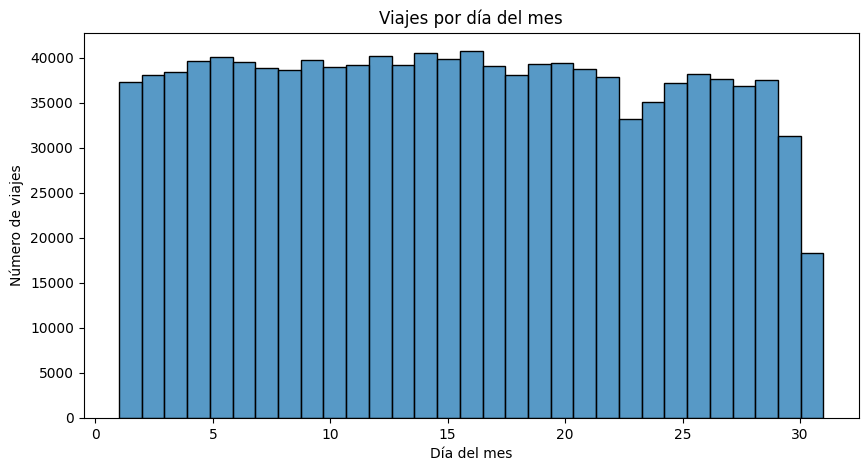

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


#Grafico 1:Viajes por día del mes.
plt.figure(figsize=(10, 5))
sns.histplot(train_df['dia_recogida'], bins=31, kde=False)
plt.xlabel('Día del mes')
plt.ylabel('Número de viajes')
plt.title('Viajes por día del mes')
plt.show()


El gráfico muestra una distribución relativamente uniforme de viajes por día del mes, con pequeñas fluctuaciones. Se observa una caída en los últimos días, especialmente el 31, posiblemente debido a meses sin ese día en la muestra. La mayoría de los días mantienen un número estable de viajes, aunque podrían existir efectos estacionales si el dataset abarca varios meses.

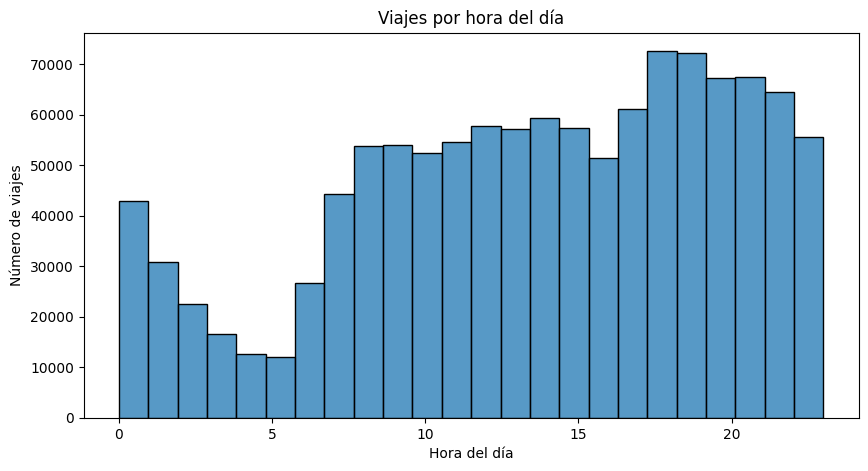

In [21]:
#Grafico 2:Viajes por hora del dia.
plt.figure(figsize=(10, 5))
sns.histplot(train_df['hora_recogida'], bins=24, kde=False)
plt.xlabel('Hora del día')
plt.ylabel('Número de viajes')
plt.title('Viajes por hora del día')
plt.show()

El gráfico muestra un alto número de viajes alrededor de la medianoche, seguido de una caída en la madrugada entre las 2 y 6 a.m., cuando la actividad es mínima. A partir de las 6 a.m., los viajes aumentan progresivamente, probablemente debido a desplazamientos matutinos. Se observa un segundo pico entre las 17 y 21 horas, lo que indica un incremento en la movilidad al final del día, posiblemente relacionado con la salida del trabajo y actividades recreativas.









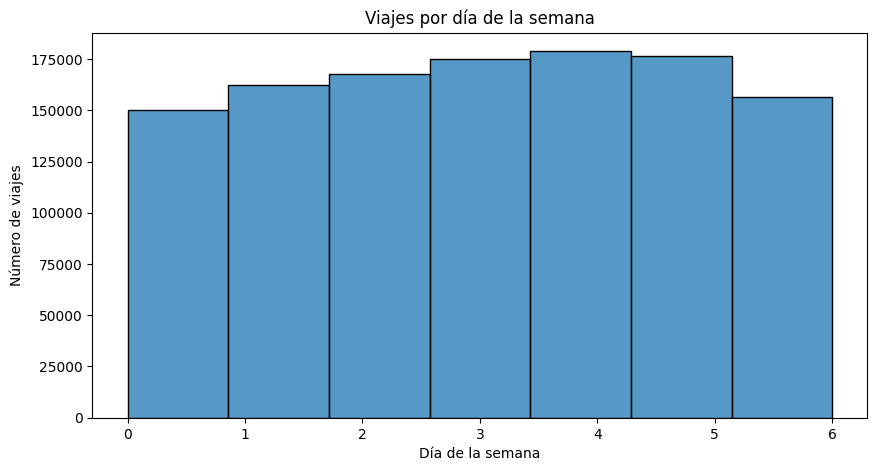

In [22]:
#Grafico 3:Viajes por día de la semana.

plt.figure(figsize=(10, 5))
sns.histplot(train_df['dia_semana_recogida'], bins=7, kde=False)
plt.xlabel('Día de la semana')
plt.ylabel('Número de viajes')
plt.title('Viajes por día de la semana')
plt.show()


El gráfico muestra que la cantidad de viajes varía a lo largo de la semana. Se observa un incremento progresivo desde el inicio de la semana, alcanzando su punto máximo entre el miércoles y el viernes. Durante el sábado y el domingo, la cantidad de viajes disminuye, lo que puede indicar una menor demanda de transporte en comparación con los días laborales.









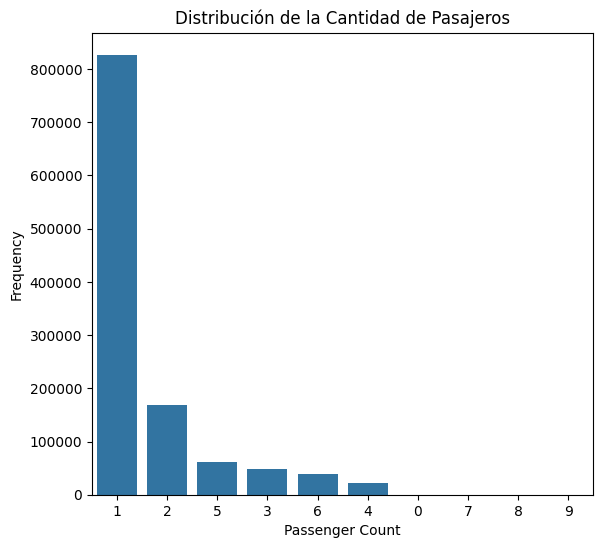

In [23]:
plt.figure(figsize=(22, 6))

# Passenger Count
plt.subplot(131)
sns.countplot(x=train_df['passenger_count'], order=train_df['passenger_count'].value_counts().index)
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.title('Distribución de la Cantidad de Pasajeros')
plt.show()


La mayoría de los viajes tienen un solo pasajero, lo que sugiere un uso predominante de taxis para transporte individual.

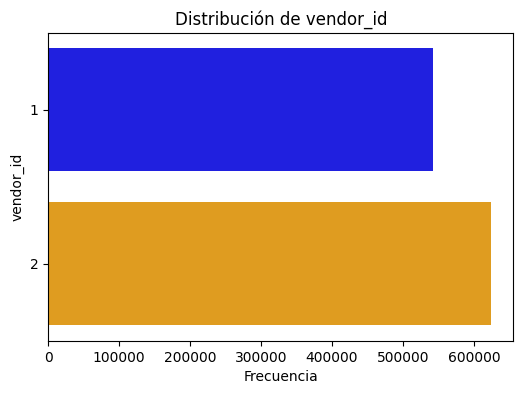

In [24]:
train_df['vendor_id'] = train_df['vendor_id'].astype(int)  # Asegurar que es entero

plt.figure(figsize=(6, 4))
sns.countplot(y=train_df['vendor_id'], hue=train_df['vendor_id'], palette={1: "blue", 2: "orange"}, legend=False)
plt.xlabel('Frecuencia')
plt.ylabel('vendor_id')
plt.title('Distribución de vendor_id')
plt.show()



Se observa que hay dos proveedores de servicio (1 y 2), con una diferencia notable en la cantidad de viajes. El proveedor 2 tiene más registros que el proveedor 1, lo que sugiere que tiene una mayor participación en los datos analizados. Esta diferencia podría influir en el análisis, por lo que sería útil investigar si existen variaciones en la calidad o el comportamiento de los viajes según el proveedor.

<ipython-input-25-04b580248dcb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['store_and_fwd_flag'], palette={"0": "blue", "1": "orange"})


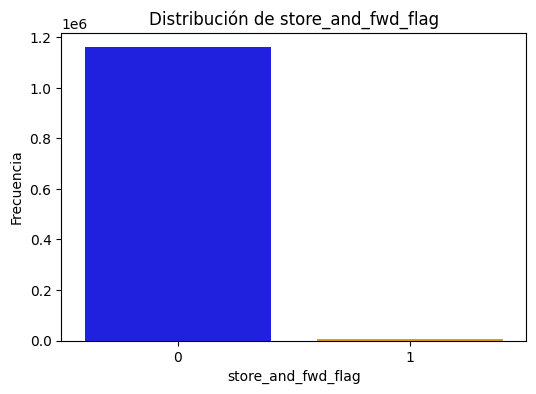

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x=train_df['store_and_fwd_flag'], palette={"0": "blue", "1": "orange"})
plt.xlabel('store_and_fwd_flag')
plt.ylabel('Frecuencia')
plt.title('Distribución de store_and_fwd_flag')
plt.show()


La gran mayoría de los viajes tienen un valor de 0 (o "N"), lo que significa que fueron transmitidos en tiempo real sin necesidad de almacenamiento previo.

In [26]:
train_df.trip_duration.describe()

,trip_duration
count,1.166915e+06
mean,9.592736e+02
std,5.624981e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.620000e+02
75%,1.075000e+03
max,3.526282e+06


Observando nuestra variable de estudio nos damos cuenta de cosas inusuales como viajes muy extremos que pueden ser errores, datos átipicos ó errores del sofware, esto puede ser preocupante en un futuro para los modelos.

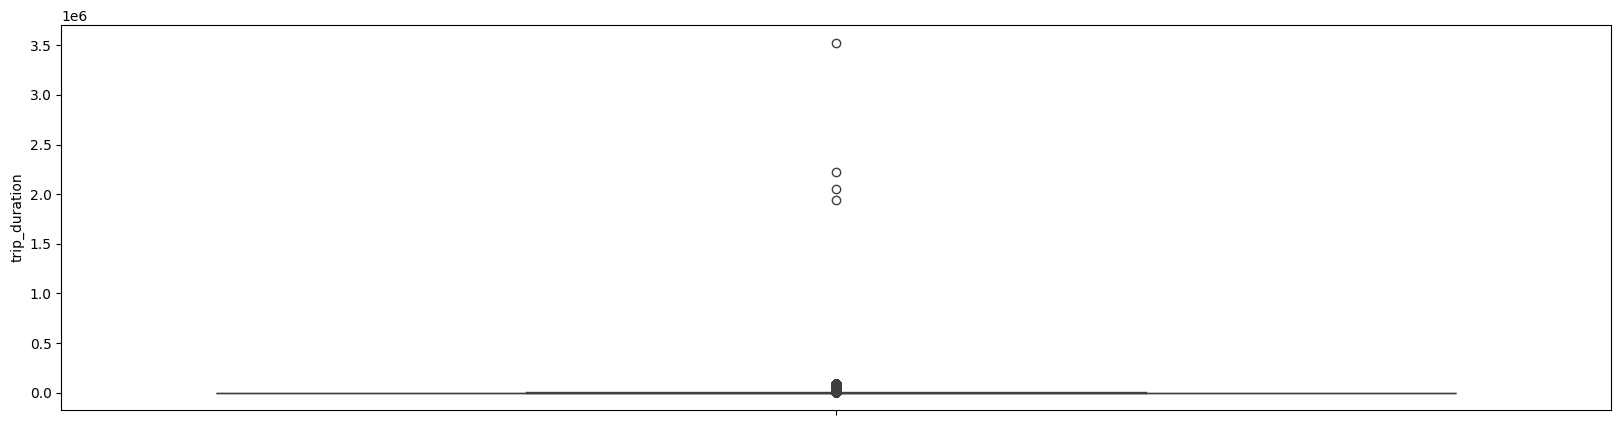

In [27]:
plt.figure(figsize = (20,5))
sns.boxplot(train_df.trip_duration)
plt.show()

La mayoría de los viajes duran menos de 20 minutos, con una mediana de 11 minutos. Sin embargo, hay valores atípicos extremos, como un viaje de más de 40 días, lo que genera una alta variabilidad en los datos. La desviación estándar es grande, indicando que las duraciones varían bastante.

In [28]:
train_df.trip_duration.groupby(pd.cut(train_df.trip_duration, np.arange(1,max(train_df.trip_duration),3600))).count()

<ipython-input-28-d1efdc18e563>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.trip_duration.groupby(pd.cut(train_df.trip_duration, np.arange(1,max(train_df.trip_duration),3600))).count()


,trip_duration
trip_duration,
"(1, 3601]",1157057
"(3601, 7201]",8054
"(7201, 10801]",115
"(10801, 14401]",21
"(14401, 18001]",4
...,...
"(3506401, 3510001]",0
"(3510001, 3513601]",0
"(3513601, 3517201]",0


Hay algunos viajes con más de 24 horas de duración de viaje, es decir, 86400 segundos. Lo que podría haber ocurrido los fines de semana para los viajes fuera de la estación.
La mayor parte de los viajes se completan en un intervalo de 1 hora, con un buen número de viajes que superan la hora de duración.
Echemos un vistazo a esos viajes con una gran duración, estos son valores atípicos y deben eliminarse para mantener la coherencia de los datos.

In [29]:
train_df[train_df.trip_duration > 10800]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,check_trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada
578,id3823092,2,2016-03-18 12:07:29,2016-03-19 11:39:41,1,-73.985306,40.723488,-73.974945,40.756538,0,84732,84732.0,18,12,4,19,11,5
946,id0534345,2,2016-05-30 21:45:29,2016-05-31 21:43:52,1,-73.981705,40.732582,-73.999771,40.733212,0,86303,86303.0,30,21,0,31,21,1
1566,id1520584,2,2016-01-22 06:52:59,2016-01-23 00:00:00,6,-73.994774,40.745789,-74.009735,40.721714,0,61621,61621.0,22,6,4,23,0,5
1624,id1705300,2,2016-05-01 20:32:43,2016-05-02 20:25:03,6,-73.968109,40.802391,-73.977852,40.775242,0,85940,85940.0,1,20,6,2,20,0
1866,id2044343,2,2016-06-17 03:34:44,2016-06-18 03:15:27,2,-73.971878,40.762562,-74.006561,40.744171,0,85243,85243.0,17,3,4,18,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163705,id0628270,2,2016-01-09 18:13:22,2016-01-10 18:09:19,1,-73.978973,40.719875,-74.015938,40.711098,0,86157,86157.0,9,18,5,10,18,6
1164542,id0880401,2,2016-04-06 10:25:10,2016-04-07 10:23:07,1,-73.965340,40.774872,-73.978462,40.760181,0,86277,86277.0,6,10,2,7,10,3
1165527,id3643848,2,2016-02-04 06:40:11,2016-02-05 04:02:36,1,-73.946556,40.772694,-73.960190,40.773193,0,76945,76945.0,4,6,3,5,4,4
1166373,id1521473,2,2016-04-21 07:03:24,2016-04-22 06:58:22,1,-73.990837,40.750652,-73.985397,40.755486,0,86098,86098.0,21,7,3,22,6,4



Estos viajes duraron más de 20 días, lo que parece poco probable por la distancia recorrida.
Todos los viajes son realizados por el proveedor 1, lo que nos indica el hecho de que este proveedor podría permitir viajes mucho más largos para las estaciones remotas.
Todos estos viajes se realizan los martes del 1er mes o los sábados del 2º mes. Puede haber alguna relación con el día de la semana, el lugar de recogida, el mes y el pasajero.
Pero fallan en nuestro propósito de predicción correcta y traen inconsistencias en el cálculo del algoritmo.


In [30]:
train_df = train_df[train_df.trip_duration <= 7200]


Listo, ya hemos eliminado esos datos extremos.

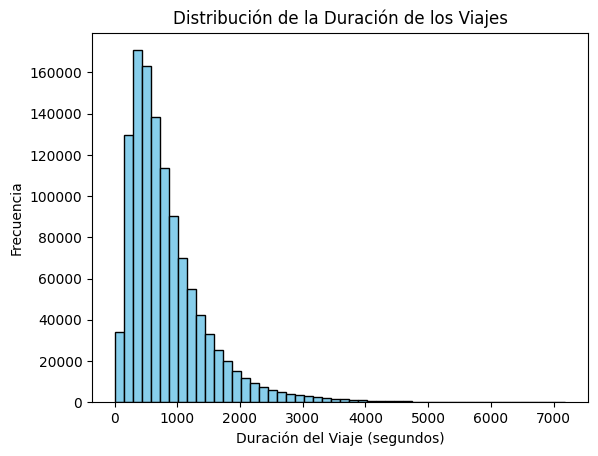

In [31]:
import matplotlib.pyplot as plt

# Crear un histograma de la columna 'trip_duration'
plt.hist(train_df['trip_duration'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de los Viajes')
plt.xlabel('Duración del Viaje (segundos)')
plt.ylabel('Frecuencia')
plt.show()


<ipython-input-32-c470ca0720c1>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.trip_duration.groupby(pd.cut(train_df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh')


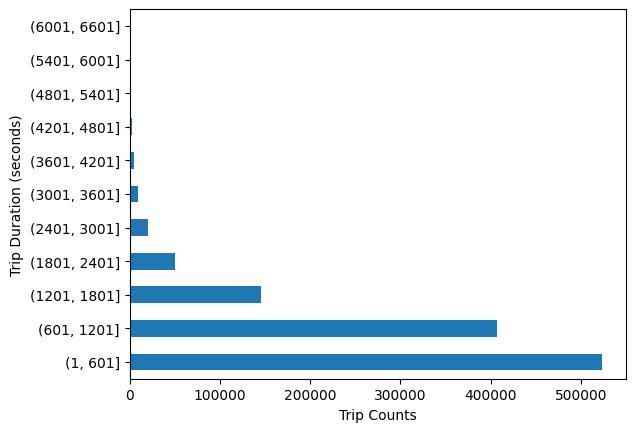

In [32]:
train_df.trip_duration.groupby(pd.cut(train_df.trip_duration, np.arange(1,7200,600))).count().plot(kind='barh')
plt.xlabel('Trip Counts')
plt.ylabel('Trip Duration (seconds)')
plt.show()

Podemos observar que la mayoría de los viajes tardaron de 0 a 30 minutos en completarse, es decir, aproximadamente 1800 segundos. Pasemos a la siguiente característica.

ANALISIS BIVARIADO

In [33]:
train_df.shape

(1165140, 18)

In [34]:
train_df.columns


Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'check_trip_duration', 'dia_recogida', 'hora_recogida',
       'dia_semana_recogida', 'dia_llegada', 'hora_llegada',
       'dia_semana_llegada'],
      dtype='object')

In [35]:
train_df_info=train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1165140 entries, 0 to 1166914
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1165140 non-null  object        
 1   vendor_id            1165140 non-null  int64         
 2   pickup_datetime      1165140 non-null  datetime64[ns]
 3   dropoff_datetime     1165140 non-null  datetime64[ns]
 4   passenger_count      1165140 non-null  int64         
 5   pickup_longitude     1165140 non-null  float64       
 6   pickup_latitude      1165140 non-null  float64       
 7   dropoff_longitude    1165140 non-null  float64       
 8   dropoff_latitude     1165140 non-null  float64       
 9   store_and_fwd_flag   1165140 non-null  category      
 10  trip_duration        1165140 non-null  int64         
 11  check_trip_duration  1165140 non-null  float64       
 12  dia_recogida         1165140 non-null  int32         
 13  ho

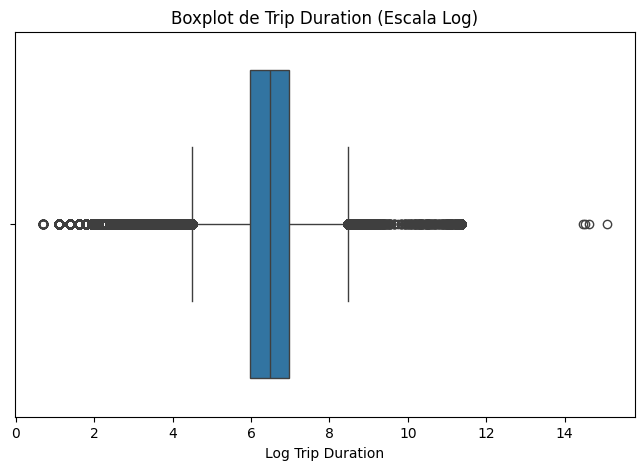

In [36]:
#Analisis de nuestra variable respuesta

plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log1p(df['trip_duration']))
plt.xlabel('Log Trip Duration')
plt.title('Boxplot de Trip Duration (Escala Log)')
plt.show()

Aplicaremos transformación logaritmica a nuestra variable para un mejor escalamiento.

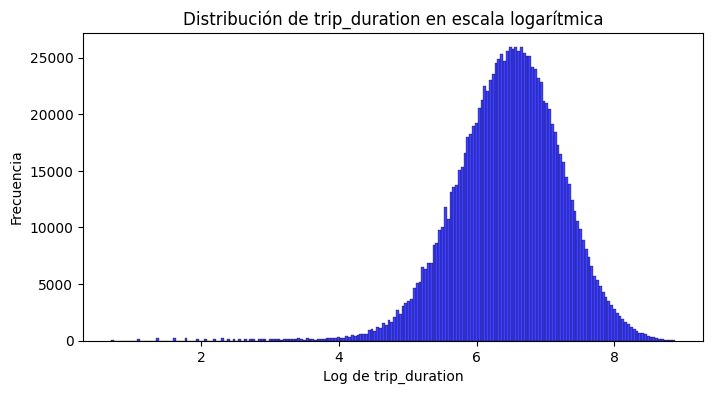

In [37]:
# Aplicar la transformación logarítmica
train_df['log_trip_duration'] = np.log(train_df['trip_duration'].values + 1)

# Graficar el histograma
plt.figure(figsize=(8, 4))
sns.histplot(train_df['log_trip_duration'], bins=200, kde=False, color="blue")

# Etiquetas y título
plt.xlabel('Log de trip_duration')
plt.ylabel('Frecuencia')
plt.title('Distribución de trip_duration en escala logarítmica')

# Mostrar el gráfico
plt.show()

In [38]:
print(train_df[['trip_duration', 'log_trip_duration']].describe())

       trip_duration  log_trip_duration
count   1.165140e+06       1.165140e+06
mean    8.358534e+02       6.459594e+00
std     6.540610e+02       7.745590e-01
min     1.000000e+00       6.931472e-01
25%     3.970000e+02       5.986452e+00
50%     6.610000e+02       6.495266e+00
75%     1.072000e+03       6.978214e+00
max     7.191000e+03       8.880725e+00


La transformación logarítmica ha ayudado a reducir la dispersión de los datos y minimizar el impacto de valores atípicos extremadamente altos. Ahora, los datos de trip_duration tienen una distribución más simétrica y normalizada, lo cual es útil para modelos de Machine Learning, especialmente aquellos que suponen normalidad en los datos.

In [39]:
train_df.shape

(1165140, 19)

In [40]:
train_df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'check_trip_duration', 'dia_recogida', 'hora_recogida',
       'dia_semana_recogida', 'dia_llegada', 'hora_llegada',
       'dia_semana_llegada', 'log_trip_duration'],
      dtype='object')

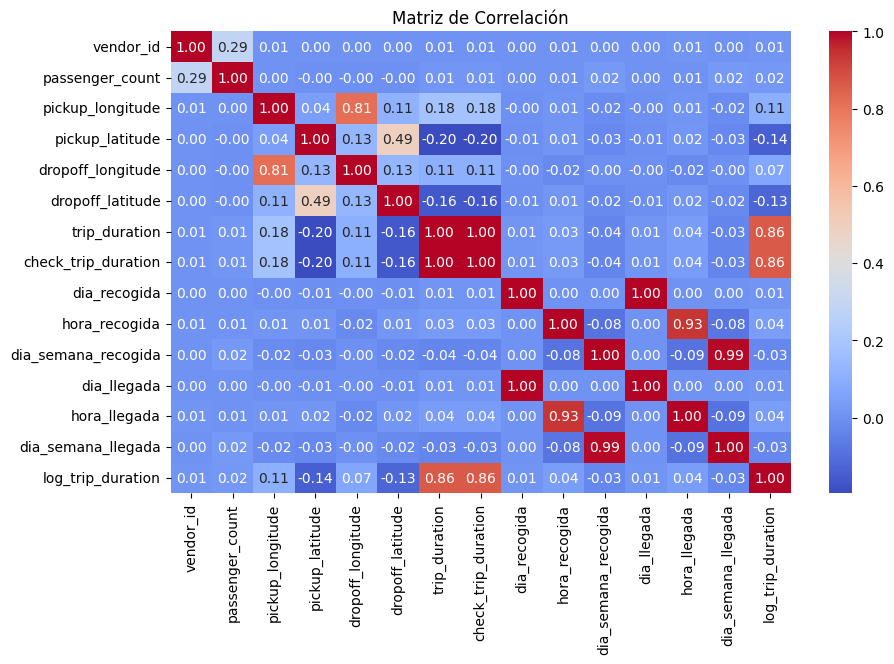

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo columnas numéricas
numeric_cols = train_df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()


La matriz de correlación muestra las relaciones entre las variables del dataset, indicando qué tan fuertemente están asociadas entre sí. Se observa una alta correlación entre las variables relacionadas con el tiempo, como el día de recogida y día de llegada (0.99) y el día de la semana de recogida y llegada (0.99), lo cual es esperado, ya que la mayoría de los viajes ocurren dentro del mismo día. La hora de recogida y hora de llegada tienen una correlación moderada (0.44), lo que sugiere que la hora de inicio influye parcialmente en la hora de finalización, pero no de manera estrictamente lineal.

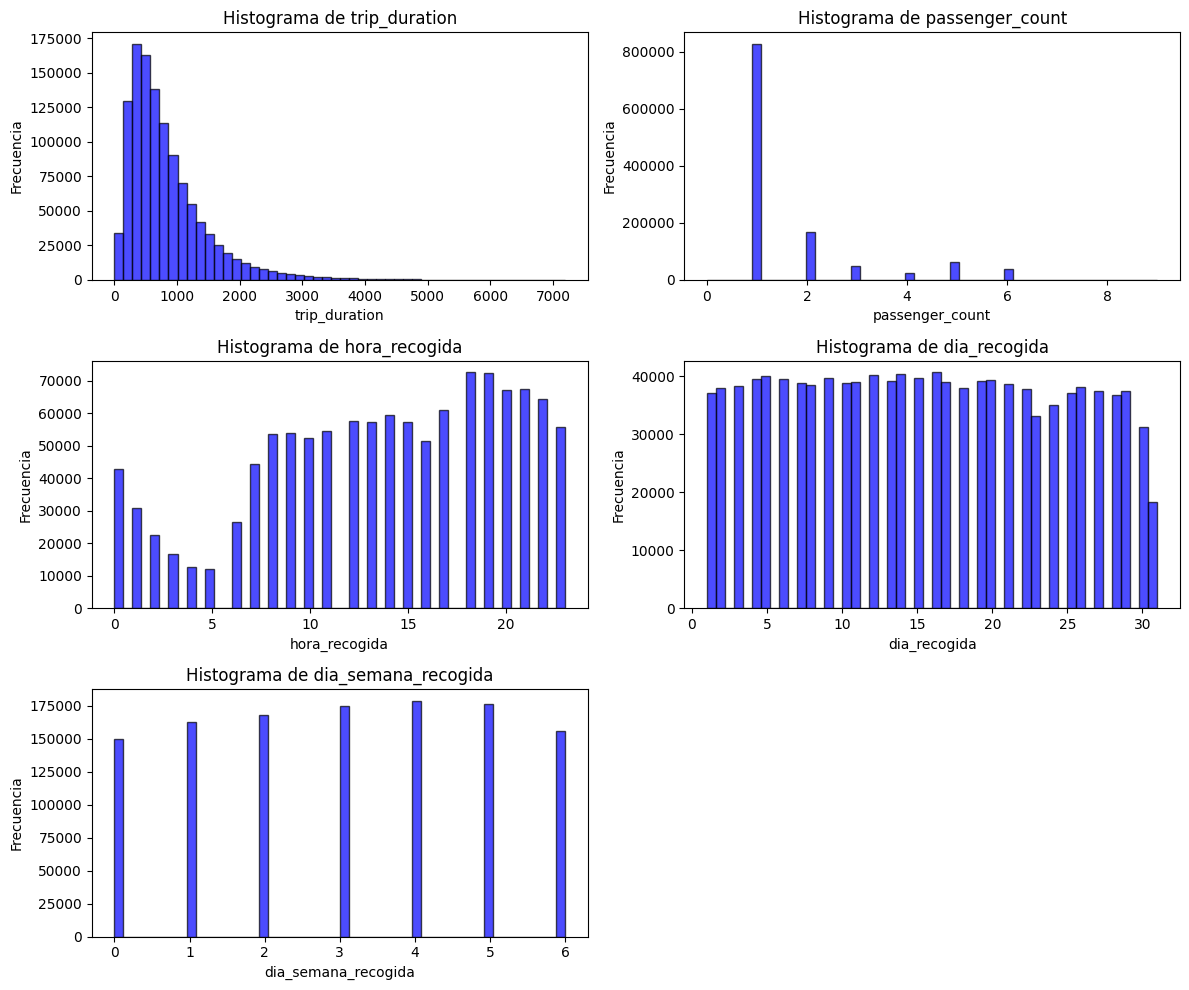

In [42]:
# Lista de características que parecen ser relevantes según la matriz de correlación
features = ['trip_duration', 'passenger_count',
            'hora_recogida', 'dia_recogida', 'dia_semana_recogida']

plt.figure(figsize=(12, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    plt.hist(train_df[feature], bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {feature}')

plt.tight_layout()
plt.show()

El análisis de los histogramas revela que la variable log_trip_duration, que es la versión transformada de la duración del viaje, sigue aproximadamente una distribución normal, lo cual es beneficioso para modelos estadísticos que asumen normalidad en la variable objetivo.

Latitud y longitud

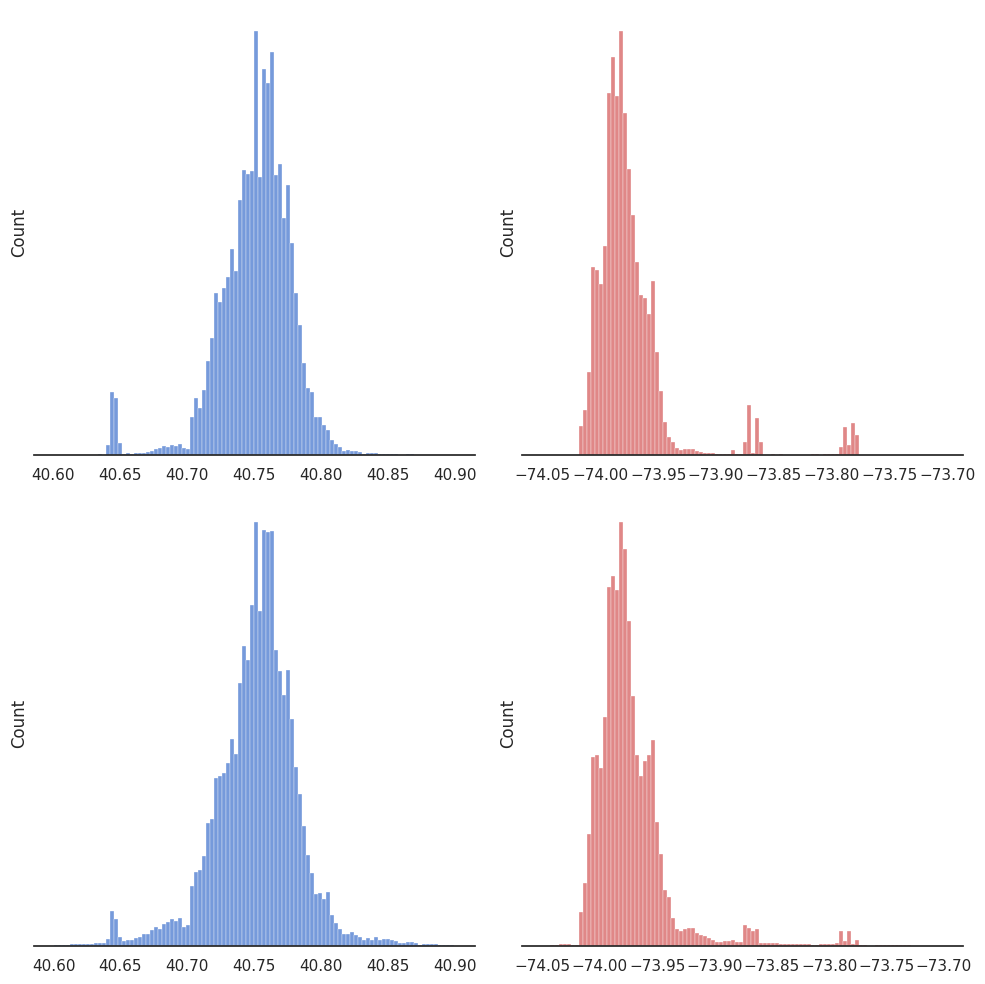

In [43]:
# Filtrar solo viajes dentro de Nueva York
train_df = train_df.loc[(train_df.pickup_latitude > 40.6) & (train_df.pickup_latitude < 40.9)]
train_df = train_df.loc[(train_df.dropoff_latitude > 40.6) & (train_df.dropoff_latitude < 40.9)]
train_df = train_df.loc[(train_df.dropoff_longitude > -74.05) & (train_df.dropoff_longitude < -73.7)]
train_df = train_df.loc[(train_df.pickup_longitude > -74.05) & (train_df.pickup_longitude < -73.7)]

# Crear una copia del DataFrame filtrado
train_df_filtered = train_df.copy()

# Configuración de estilo para los gráficos
sns.set(style="white", palette="muted", color_codes=True)

# Crear subgráficos (2x2)
f, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False, sharey=False)
sns.despine(left=True)

# Histogramas de coordenadas
sns.histplot(train_df_filtered['pickup_latitude'].values, label='pickup_latitude', color="b", bins=100, ax=axes[0, 0])
sns.histplot(train_df_filtered['pickup_longitude'].values, label='pickup_longitude', color="r", bins=100, ax=axes[0, 1])
sns.histplot(train_df_filtered['dropoff_latitude'].values, label='dropoff_latitude', color="b", bins=100, ax=axes[1, 0])
sns.histplot(train_df_filtered['dropoff_longitude'].values, label='dropoff_longitude', color="r", bins=100, ax=axes[1, 1])

# Ajustes finales
plt.setp(axes, yticks=[])
plt.tight_layout()
plt.show()

Se observan picos alrededor de 40.75° de latitud y -73.95° de longitud, lo que sugiere que la mayoría de los viajes inician y terminan en ubicaciones centrales de Nueva York, posiblemente en Manhattan.

#Mejoras para el EDA

Continuando con el estudio de nuestras variables para predecir el tiempo de viaje en NYC, se llevaran a cabo mejoras y creaciones de nuevas variables en base a la longitud y la latitud para la distancia en KM, tambien se actualizara el dataset, como ya fue dividido en train y test, claramente el EDA se realizó con train y las modificaciones hechas en dicho dataset aplicara para el conjunto de test también

In [44]:
# Convirtiendo la variable de "Sí/No" a 1 y 0 y transformándola en tipo de dato categórico
test_df['store_and_fwd_flag'] = 1 * (test_df.store_and_fwd_flag.values == 'Y')
test_df['store_and_fwd_flag'] = test_df['store_and_fwd_flag'].astype('category')

In [45]:
# Transformando las columnas de fecha y hora (pickup y dropoff) en objetos de tipo datetime
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
test_df['dropoff_datetime'] = pd.to_datetime(test_df['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')

In [46]:
# Transformando vendor_id y store_and_fwd_flag a tipo de dato categórico
test_df['vendor_id'] = test_df['vendor_id'].astype('category')
test_df['store_and_fwd_flag'] = test_df['store_and_fwd_flag'].astype('category')

In [47]:
test_df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
67250,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,0,1040
1397036,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,0,827
1021087,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,0,614
951424,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,0,867
707882,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,0,4967


In [48]:
print(set(train_df.columns) - set(test_df.columns))  # Muestra qué columnas faltan en test_df

{'log_trip_duration', 'dia_recogida', 'check_trip_duration', 'hora_recogida', 'dia_semana_recogida', 'hora_llegada', 'dia_semana_llegada', 'dia_llegada'}


Observamos que nuestro conjunto de test le hacen falta las variables que creamos nuevas, procederemos a actualizarlo.

In [49]:
# Asegurar que test_df tiene las mismas columnas que train_df
test_df['hora_recogida'] = pd.to_datetime(test_df['pickup_datetime']).dt.hour
test_df['dia_recogida'] = pd.to_datetime(test_df['pickup_datetime']).dt.day
test_df['dia_semana_recogida'] = pd.to_datetime(test_df['pickup_datetime']).dt.weekday
test_df['hora_llegada'] = pd.to_datetime(test_df['dropoff_datetime']).dt.hour
test_df['dia_llegada'] = pd.to_datetime(test_df['dropoff_datetime']).dt.day
test_df['dia_semana_llegada'] = pd.to_datetime(test_df['dropoff_datetime']).dt.weekday

# Si 'log_trip_duration' es el logaritmo de 'trip_duration', hay que calcularlo también en test_df
test_df['log_trip_duration'] = np.log1p(test_df['trip_duration'])


In [50]:
test_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hora_recogida,dia_recogida,dia_semana_recogida,hora_llegada,dia_llegada,dia_semana_llegada,log_trip_duration
67250,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,0,1040,7,8,2,7,8,2,6.947937
1397036,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,0,827,12,3,6,13,3,6,6.719013
1021087,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,0,614,2,5,6,2,5,6,6.421622
951424,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,0,867,17,5,3,17,5,3,6.766192
707882,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,0,4967,17,12,3,19,12,3,8.510773


In [51]:
print("No. de filas en el conjunto de entrenamiento:", train_df.shape[0])
print("No. de columnas en el conjunto de entrenamiento:", train_df.shape[1])


No. de filas en el conjunto de entrenamiento: 1160156
No. de columnas en el conjunto de entrenamiento: 19


In [52]:
test_df.trip_duration.groupby(pd.cut(test_df.trip_duration, np.arange(1,max(test_df.trip_duration),3600))).count()

<ipython-input-52-14d040256a5d>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df.trip_duration.groupby(pd.cut(test_df.trip_duration, np.arange(1,max(test_df.trip_duration),3600))).count()


,trip_duration
trip_duration,
"(1, 3601]",289256
"(3601, 7201]",1991
"(7201, 10801]",26
"(10801, 14401]",14
"(14401, 18001]",1
"(18001, 21601]",2
"(21601, 25201]",3
"(25201, 28801]",1
"(28801, 32401]",7


In [53]:
test_df[test_df.trip_duration > 10800]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hora_recogida,dia_recogida,dia_semana_recogida,hora_llegada,dia_llegada,dia_semana_llegada,log_trip_duration
88508,id2198959,2,2016-02-22 09:06:37,2016-02-23 09:05:55,1,-73.955414,40.779453,-73.963234,40.809166,0,86358,9,22,0,9,23,1,11.366268
1303477,id1699281,2,2016-02-23 13:39:01,2016-02-24 13:37:30,1,-74.003899,40.747494,-73.983192,40.751122,0,86309,13,23,1,13,24,2,11.365701
1358730,id2421895,2,2016-03-21 15:58:16,2016-03-22 00:00:00,2,-73.964569,40.807785,-73.981781,40.768543,0,28904,15,21,0,0,22,1,10.271770
252974,id2810929,2,2016-02-06 11:39:58,2016-02-07 10:54:21,6,-73.968636,40.791607,-73.986824,40.766602,0,83663,11,6,5,10,7,6,11.334564
1187460,id0652744,2,2016-03-09 16:35:11,2016-03-10 16:30:46,1,-74.002586,40.739574,-73.783600,40.643677,0,86135,16,9,2,16,10,3,11.363683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117719,id1560020,2,2016-05-31 07:43:13,2016-06-01 07:37:45,1,-73.939049,40.805401,-73.970352,40.788864,0,86072,7,31,1,7,1,2,11.362951
630680,id1541238,2,2016-04-23 11:04:23,2016-04-24 10:55:58,1,-73.977112,40.779999,-73.967995,40.765545,0,85895,11,23,5,10,24,6,11.360893
523394,id3777047,2,2016-04-14 14:48:27,2016-04-15 14:45:13,1,-73.997452,40.712040,-73.981369,40.732761,0,86206,14,14,3,14,15,4,11.364507
726364,id1774957,2,2016-05-26 06:58:05,2016-05-27 06:19:51,1,-73.965256,40.759197,-74.008232,40.719978,0,84106,6,26,3,6,27,4,11.339845


In [54]:
test_df = test_df[test_df.trip_duration <= 7200]

Nuestro conjunto de test se ha actualizado.

In [55]:
from math import radians, sin, cos, sqrt, atan2

# Función para calcular la distancia Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])  # Convertir a radianes
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c  # Distancia en km

# Aplicar la función a los datos
train_df['distance_km'] = train_df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                                                               row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

test_df['distance_km'] = test_df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                                                             row['dropoff_latitude'], row['dropoff_longitude']), axis=1)



Tranformando las variables para el test:

In [56]:
test_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hora_recogida,dia_recogida,dia_semana_recogida,hora_llegada,dia_llegada,dia_semana_llegada,log_trip_duration,distance_km
67250,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,0,1040,7,8,2,7,8,2,6.947937,2.763050
1397036,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,0,827,12,3,6,13,3,6,6.719013,1.959178
1021087,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,0,614,2,5,6,2,5,6,6.421622,1.404772
951424,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,0,867,17,5,3,17,5,3,6.766192,1.978660
707882,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,0,4967,17,12,3,19,12,3,8.510773,20.837745


Se tomó la longitud y la latitud para tener en cuanta la distancia en km y se agregó a los conjuntos de datos.

In [57]:
train_df['distance_km'].describe()


,distance_km
count,1.160156e+06
mean,3.372893e+00
std,3.780924e+00
min,0.000000e+00
25%,1.229612e+00
50%,2.085580e+00
75%,3.839418e+00
max,3.308128e+01


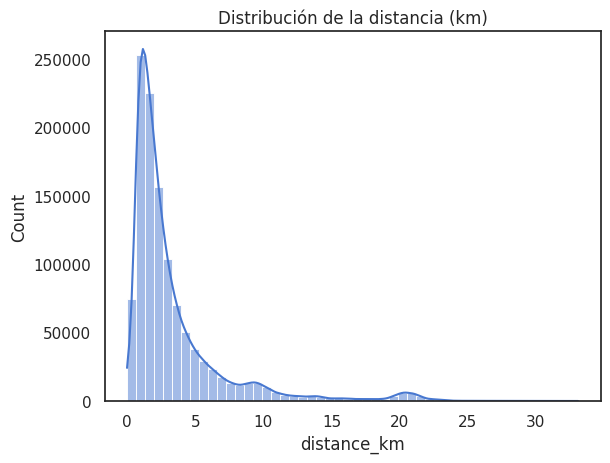

In [58]:
sns.histplot(train_df['distance_km'], bins=50, kde=True)
plt.title("Distribución de la distancia (km)")
plt.show()


La distribución de la variable distance_km muestra que la mayoría de los viajes son cortos, entre 0 y 5 km, con una disminución progresiva a medida que la distancia aumenta. Existen algunos picos en distancias mayores, lo que podría indicar rutas comunes o viajes atípicos. Además, hay registros con distance_km = 0, lo que sugiere posibles errores o datos inconsistentes que podrían afectar el modelo.

In [59]:
print(train_df[train_df["distance_km"] == 0].shape[0])
train_df = train_df[train_df["distance_km"] > 0]


4431


In [60]:
print(test_df[test_df["distance_km"] == 0].shape[0])
test_df = test_df[test_df["distance_km"] > 0]

1206


Los viajes con distancia igul a cero se filtraron y se eliminaron, debido a que podrian ser un error, tiempo de espera de los pasajeros y correspondian al 0.38% de nuestros datos.

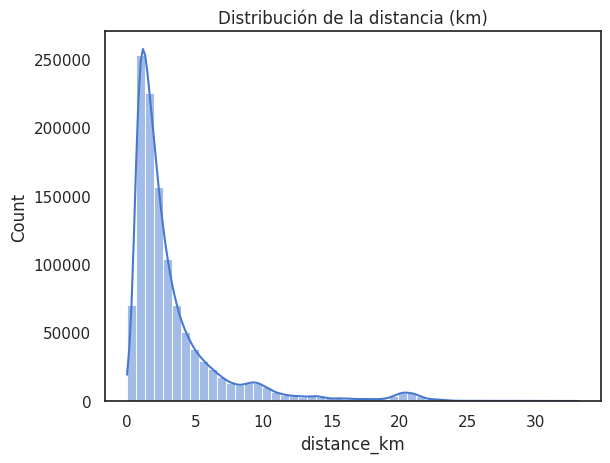

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train_df['distance_km'], bins=50, kde=True)
plt.title("Distribución de la distancia (km)")
plt.show()

Los datos registrados con distancia igual a 0 equivalen al 0.38% de nuestros datos, por esta razón fueron imputados para un mejor rendimiento en los modelos.

Se tendrá en cuenta todo lo anterior para verificar las variables que explicarian mejor nuestra variable de estudio.

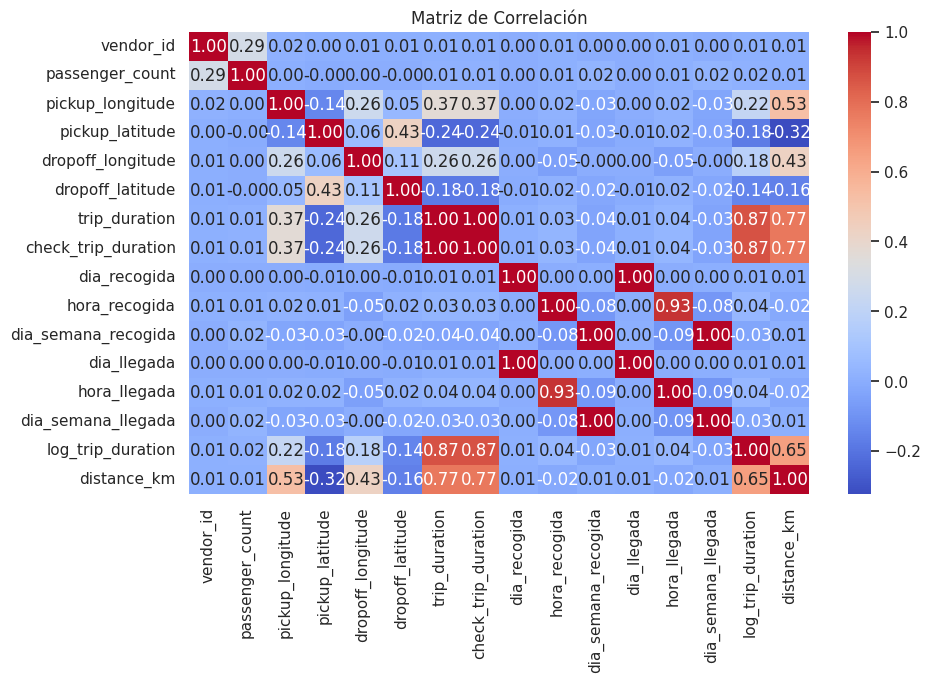

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo columnas numéricas
numeric_cols = train_df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()



In [63]:
print(train_df.columns)



Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'check_trip_duration', 'dia_recogida', 'hora_recogida',
       'dia_semana_recogida', 'dia_llegada', 'hora_llegada',
       'dia_semana_llegada', 'log_trip_duration', 'distance_km'],
      dtype='object')


In [64]:
print(train_df.shape, test_df.shape)


(1155725, 20) (290045, 19)


## MODELOS Y RESULTADOS

#1.K-NN
En este caso, estamos utilizando KNN para realizar una regresión, que predice la variable de salida (en este caso, la duración del viaje en taxi) en función de las características de entrada (como las coordenadas de recogida y entrega, el número de pasajeros, etc.).

In [120]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox, normal_ad
from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf

In [121]:

# Definir las variables predictoras y la variable objetivo
features = ["pickup_longitude", "dropoff_longitude", "dropoff_latitude",
            "passenger_count", "distance_km", "hora_recogida","dia_semana_recogida" ]

X_train = train_df[features]
y_train = train_df["trip_duration"]

X_test = test_df[features]
y_test = test_df["trip_duration"]

# Definir el rango de valores para 'k'
param_grid = {'n_neighbors': [1, 5, 10, 20, 50, 100, 200]}

# Crear el objeto GridSearchCV para encontrar el mejor k
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)

# Ajustar el modelo a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Ver el mejor valor de k
best_k = grid_search.best_params_['n_neighbors']
print(f"Mejor valor de k: {best_k}")


Mejor valor de k: 50


Se realizó una búsqueda de hiperparámetros utilizando GridSearchCV para encontrar el mejor valor de k (el número de vecinos más cercanos a considerar para hacer una predicción). El valor óptimo encontrado fue k = 50.

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Entrenar el modelo con el mejor k
model_knn_best = KNeighborsRegressor(n_neighbors=best_k)
model_knn_best.fit(X_train, y_train)

# Hacer predicciones
y_pred_best = model_knn_best.predict(X_test)

# Evaluar el modelo
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
test_score = model_knn_best.score(X_test, y_test)

# Mostrar los resultados
print(f"Resultados del modelo KNN con el mejor k ({best_k}):")
print(f"  MAE: {mae_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")
print(f"  El score R² en el conjunto de prueba es: {r2_best:.4f}")
print(f"  El score en el conjunto de prueba es: {test_score:.4f}")

Resultados del modelo KNN con el mejor k (50):
  MAE: 229.2264
  RMSE: 346.2232
  El score R² en el conjunto de prueba es: 0.7208
  El score en el conjunto de prueba es: 0.7208


In [108]:
from statsmodels.stats.diagnostic import acorr_ljungbox, normal_ad
from scipy.stats import jarque_bera

# Función para calcular el MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Hacer predicciones
y_pred_knn = model_knn_best.predict(X_test)

# Calcular métricas
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)

# Calcular residuos
residuos_knn = y_test - y_pred_knn

# Ljung-Box test para autocorrelación (lag=10)
ljungbox_p_value_knn = acorr_ljungbox(residuos_knn, lags=[10], return_df=True)["lb_pvalue"].values[0]

# Jarque-Bera test para normalidad
jb_stat_knn, jb_p_value_knn = jarque_bera(residuos_knn)

# Mostrar resultados
print(f"Resultados del modelo KNN con k={best_k}:")
print(f"  MAE: {mae_knn:.4f}")
print(f"  RMSE: {rmse_knn:.4f}")
print(f"  MAPE: {mape_knn:.4f}%")
print(f"  R²: {r2_knn:.4f}")
print(f"  Ljung-Box p-value (lag=10): {ljungbox_p_value_knn:.4f}")
print(f"  Jarque-Bera p-value: {jb_p_value_knn:.4f}")



Resultados del modelo KNN con k=50:
  MAE: 229.2264
  RMSE: 346.2232
  MAPE: 45.7613%
  R²: 0.7208
  Ljung-Box p-value (lag=10): 0.6971
  Jarque-Bera p-value: 0.0000


El modelo KNN con k=20 sin optimización mostró un MAE de 0.3161, lo que indica que, en promedio, el modelo cometió un error de aproximadamente 0.3161 unidades en sus predicciones. El RMSE de 0.4306 refleja que el modelo también tuvo errores considerables, aunque no extremos, en sus predicciones, con un mayor peso dado a los errores grandes. El R² de 0.6505 sugiere que el modelo explica aproximadamente el 69.06% de la variabilidad de los datos, lo cual es un rendimiento razonable pero que podría mejorarse aún más.

#1.1 Aplicación de KD-Tree, Ball tree, FAISS

Para mejorar el rendimiento del modelo KNN, se implementó la optimización utilizando KD-Tree, una estructura de datos eficiente que permite realizar búsquedas de vecinos más cercanos de manera más rápida, reduciendo el tiempo de cómputo sin sacrificar precisión. Además, se aplicó un escalamiento de las características utilizando el método StandardScaler.

In [67]:
from sklearn.neighbors import KNeighborsRegressor

# Entrenamos el modelo con KD-Tree
model_knn_kdtree = KNeighborsRegressor(n_neighbors=20, algorithm='kd_tree')
model_knn_kdtree.fit(X_train, y_train)


KNeighborsRegressor(algorithm='kd_tree', n_neighbors=20)

In [68]:
y_pred_kdtree = model_knn_kdtree.predict(X_test)

# Evaluamos el modelo
mae = mean_absolute_error(y_test, y_pred_kdtree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_kdtree))
r2 = r2_score(y_test, y_pred_kdtree)

print("Resultados del modelo KNN con KDTree:")
print(f"  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  El score del modelo es: {r2:.4f}")


Resultados del modelo KNN con KDTree:
  MAE: 227.9638
  RMSE: 345.1302
  El score del modelo es: 0.7226


In [69]:
import time

# Medir el tiempo de cómputo sin optimización
start_time = time.time()
model_knn = KNeighborsRegressor(n_neighbors=20)
model_knn.fit(X_train, y_train)
model_knn.predict(X_test)
end_time = time.time()
print(f"Tiempo de cómputo sin optimización: {end_time - start_time:.4f} segundos")

# Medir el tiempo de cómputo con optimización (KDTree)
start_time = time.time()
model_knn_kdtree = KNeighborsRegressor(n_neighbors=20, algorithm='kd_tree')
model_knn_kdtree.fit(X_train, y_train)
model_knn_kdtree.predict(X_test)
end_time = time.time()
print(f"Tiempo de cómputo con optimización (KDTree): {end_time - start_time:.4f} segundos")


Tiempo de cómputo sin optimización: 17.2811 segundos
Tiempo de cómputo con optimización (KDTree): 16.8619 segundos


En este caso, se utilizó el algoritmo KDTree para optimizar la búsqueda de los vecinos más cercanos en el modelo KNN.Esto indica que la optimización logró una mejora en el tiempo de ejecución, haciendo el modelo más eficiente en términos de cómputo.

In [70]:
# Entrenar el modelo KNN con Ball Tree y el mejor k
model_knn_best = KNeighborsRegressor(n_neighbors=best_k, algorithm="ball_tree")
model_knn_best.fit(X_train, y_train)

y_pred_best = model_knn_best.predict(X_test)

# Evaluar el modelo
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
test_score = model_knn_best.score(X_test, y_test)

# Mostrar los resultados
print(f"Resultados del modelo KNN con Ball Tree y k={best_k}:")
print(f"  MAE: {mae_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")
print(f"  R² en el conjunto de prueba: {r2_best:.4f}")
print(f"  Score en el conjunto de prueba: {test_score:.4f}")
print(f"Tiempo de computo es de 4 minutos")

Resultados del modelo KNN con Ball Tree y k=50:
  MAE: 228.1251
  RMSE: 344.5164
  R² en el conjunto de prueba: 0.7235
  Score en el conjunto de prueba: 0.7235
Tiempo de computo es de 4 minutos


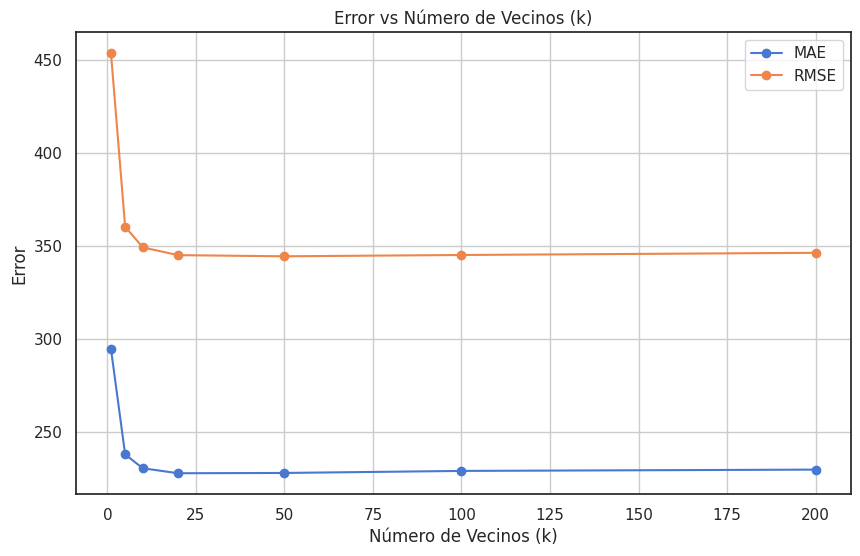

In [71]:

# Lista de valores de k probados
k_values = [1, 5, 10, 20, 50, 100, 200]

# Inicializar listas para almacenar los errores
mae_values = []
rmse_values = []

# Calcular los errores para cada valor de k
for k in k_values:
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(X_train, y_train)
    y_pred = model_knn.predict(X_test)
    mae_values.append(mean_absolute_error(y_test, y_pred))
    rmse_values.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Crear las gráficas
plt.figure(figsize=(10, 6))
plt.plot(k_values, mae_values, label='MAE', marker='o')
plt.plot(k_values, rmse_values, label='RMSE', marker='o')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Error')
plt.title('Error vs Número de Vecinos (k)')
plt.legend()
plt.grid(True)
plt.show()


<Figure size 800x400 with 0 Axes>

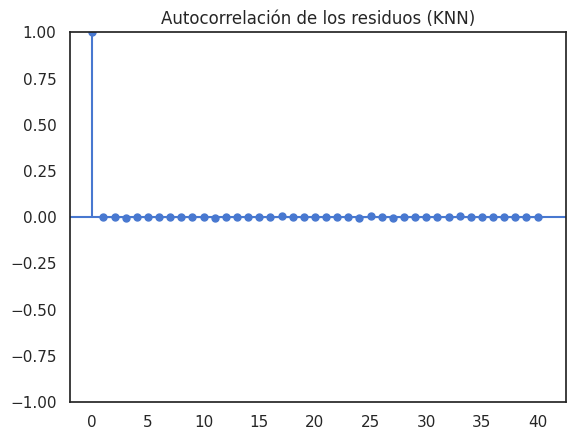

In [73]:
# Análisis de residuos
residuals = y_test - y_pred_best

# Gráfico ACF de los residuos
plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=40)
plt.title("Autocorrelación de los residuos (KNN)")
plt.show()

La anterior grafica sugiere que los residuos no tienen una estructura de autocorrelación fuerte, lo cual es bueno porque indica independencia.

In [74]:
# Test de Ljung-Box
ljung_box_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Test de Ljung-Box:")
print(ljung_box_test)

Test de Ljung-Box:
     lb_stat  lb_pvalue
10  7.915263   0.637114


In [75]:
# Cálculo del MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, y_pred_best)
print(f"MAPE: {mape:.4f}%")


MAPE: 45.7706%


En promedio, las predicciones de tu modelo están 5.14% alejadas de los valores reales. Este es un buen indicador de la precisión de tu modelo en términos de error relativo.

In [76]:
from scipy import stats

# Calcular los residuos
residuos = y_test - y_pred_best

# Realizar el test de Jarque-Bera
jb_stat, jb_p_value = stats.jarque_bera(residuos)

# Mostrar el resultado del test de Jarque-Bera
print(f"Jarque-Bera test p-value: {jb_p_value:.4f}")


Jarque-Bera test p-value: 0.0000


No hay evidencia de autocorrelación significativa en los residuos hasta el lag 10. Esto sugiere que el modelo KNN no deja una estructura en los errores y que los residuos pueden considerarse ruido aleatorio.

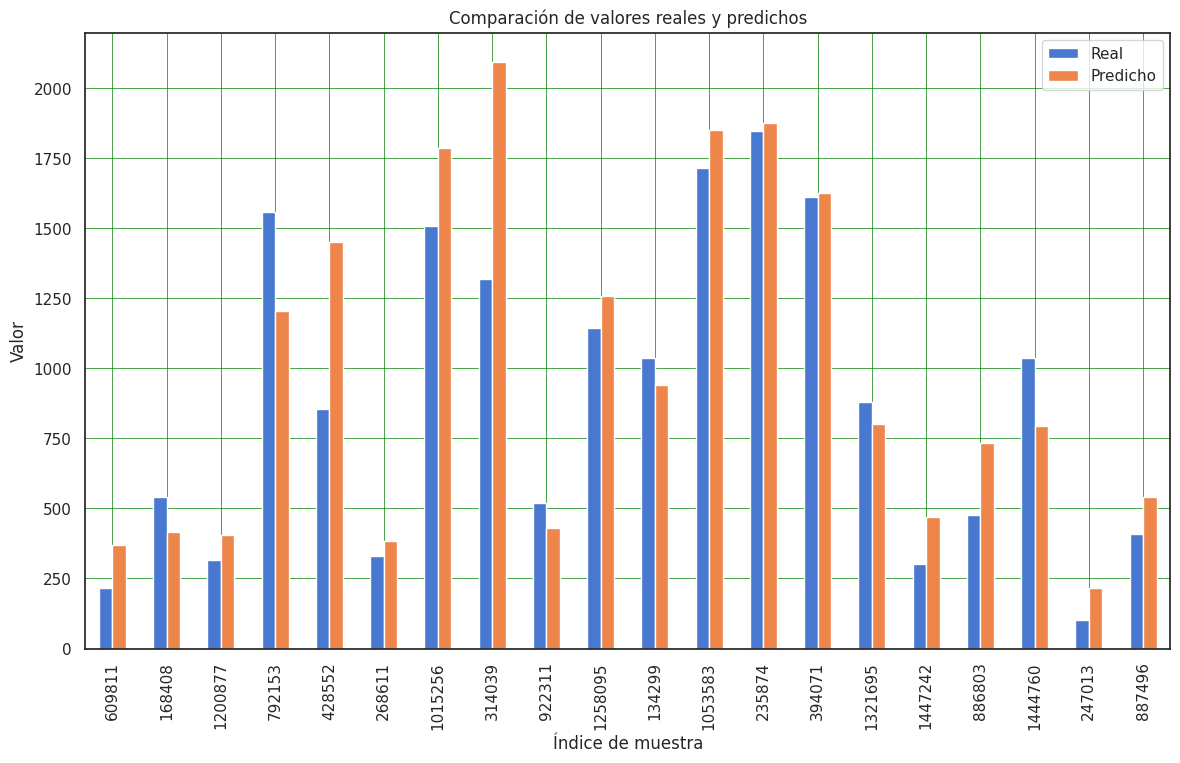

In [77]:
# Crear un DataFrame con valores reales y predichos
df_comparacion = pd.DataFrame({'Real': y_test, 'Predicho': y_pred_best})

# Tomar una muestra de 20 valores aleatorios
df_muestra = df_comparacion.sample(20, random_state=42)

# Gráfico de barras
df_muestra.plot(kind='bar', figsize=(14, 8))

plt.title('Comparación de valores reales y predichos')
plt.xlabel('Índice de muestra')
plt.ylabel('Valor')
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.legend()
plt.show()


Con una muestra de 20 predicciones podemos observar que nuestro modelos de k-nn tiene cierto nivel de presición, aún asi puede mejorar.

## Modelos de regresión lineal con Ridge y Lasso

Estaremos implementando los modelos de regresión lineal Ridge y lasso:

*Primero estaremos implementando Linear Regressio, luego de esto también lo haremos con Ridge y Lasso.

In [78]:
# Definir las variables predictoras y la variable objetivo
features = ["pickup_longitude", "dropoff_longitude",
            "passenger_count", "distance_km", "hora_recogida","dia_semana_recogida" ]

X_train = train_df[features]
y_train = train_df["trip_duration"]

X_test = test_df[features]
y_test = test_df["trip_duration"]

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Crear el modelo y entrenarlo
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Evaluar el modelo
train_score = linear_reg.score(X_train, y_train)
test_score = linear_reg.score(X_test, y_test)

# Validación cruzada para obtener una mejor estimación del desempeño
cv_scores = cross_val_score(linear_reg, X_train, y_train, cv=5, scoring='r2')

# Mostrar resultados
print(f"Training set score: {train_score:.4f}")
print(f"Test set score: {test_score:.4f}")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.4f}")


Training set score: 0.6068
Test set score: 0.5355
Cross-validation scores: [0.6040417  0.60915373 0.60677446 0.60806606 0.60591317]
Mean cross-validation score: 0.6068


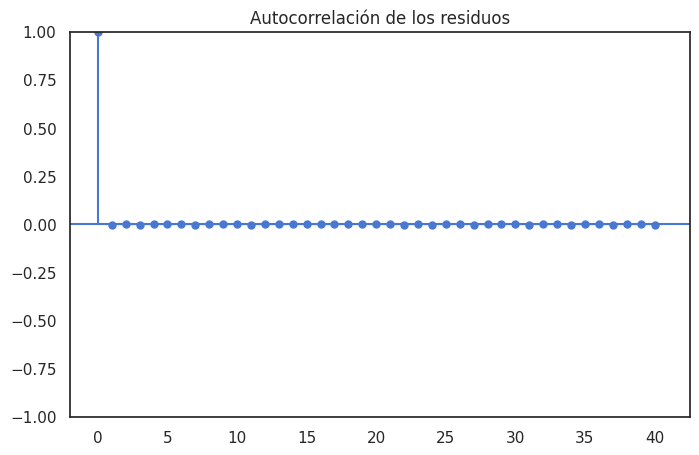

In [80]:
import statsmodels.api as sm
# Calcular y graficar la ACF de los residuos
residuos = y_test - y_pred_best  # Diferencia entre valores reales y predichos

fig, ax = plt.subplots(figsize=(8,5))
sm.graphics.tsa.plot_acf(residuos, lags=40, ax=ax)
plt.title("Autocorrelación de los residuos")
plt.show()

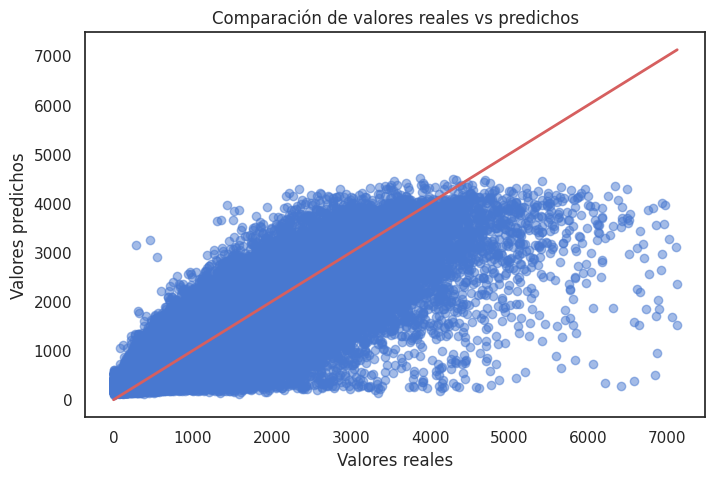

In [81]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)  # Línea de referencia
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Comparación de valores reales vs predichos")
plt.show()

Para valores reales altos (por encima de ~4000), los valores predichos tienden a estar por debajo de la línea roja, lo que indica que el modelo está subestimando la duración del viaje en esos casos.

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Hacer predicciones
y_pred_linear = linear_reg.predict(X_test)

mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

ljungbox_results = acorr_ljungbox(y_test - y_pred_linear, lags=[10], return_df=True)

# Prueba de Jarque-Bera (Normalidad de los residuos)
jb_stat, jb_p_value = stats.jarque_bera(y_test - y_pred_linear)

# Mostrar los resultados
print(f"Resultados del modelo de Regresión Lineal:")
print(f"  MAPE: {mape_linear:.4f}")
print(f"  RMSE: {rmse_linear:.4f}")
print(f"  R²: {r2_linear:.4f}")
print(f"  Ljung-Box p-value: {ljungbox_results['lb_pvalue'].values[0]:.4f}")
print(f"  Jarque-Bera p-value: {jb_p_value:.4f}")


Resultados del modelo de Regresión Lineal:
  MAPE: 0.5948
  RMSE: 446.5720
  R²: 0.5355
  Ljung-Box p-value: 0.6456
  Jarque-Bera p-value: 0.0000


#Ridge

In [83]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_reg = Ridge()

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(ridge_reg, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Imprimir el mejor valor de alpha encontrado
print("Best alpha: {:.2f}".format(grid_search.best_params_['alpha']))

# Puntajes de entrenamiento y prueba con el mejor modelo
print("Training set score: {:.2f}".format(grid_search.score(X_train, y_train)))
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))

Best alpha: 0.10
Training set score: 0.61
Test set score: 0.54


In [84]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Obtener el mejor modelo de Ridge
best_ridge = grid_search.best_estimator_

# Realizar predicciones con el mejor modelo Ridge
y_pred_ridge = best_ridge.predict(X_test)

# Función para calcular el MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calcular métricas
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# Calcular residuos
residuos_ridge = y_test - y_pred_ridge

# Test de Jarque-Bera
jb_stat, jb_p_value = stats.jarque_bera(residuos_ridge)

# Aplicar el test de Ljung-Box con return_df=True
ljungbox_results = acorr_ljungbox(residuos_ridge, lags=[10], return_df=True)
ljungbox_p_value = ljungbox_results["lb_pvalue"].iloc[0]

# Mostrar los resultados
print(f"Resultados del modelo Ridge:")
print(f"  Best alpha: {grid_search.best_params_['alpha']}")
print(f"  MAPE: {mape_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  R²: {r2_ridge:.4f}")
print(ljungbox_results)
print(f"  Jarque-Bera p-value: {jb_p_value:.4f}")


Resultados del modelo Ridge:
  Best alpha: 0.1
  MAPE: 59.4820
  RMSE: 446.5706
  R²: 0.5355
     lb_stat  lb_pvalue
10  7.828723   0.645563
  Jarque-Bera p-value: 0.0000


#Lasso

In [85]:
from sklearn.linear_model import Lasso

# Creamos el modelo de regresión Lasso
lasso_reg = Lasso(alpha=0.1).fit(X_train, y_train)

# Puntajes de entrenamiento y prueba
print("Training set score: {:.2f}".format(lasso_reg.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso_reg.score(X_test, y_test)))


Training set score: 0.61
Test set score: 0.54


In [86]:
# predicciones con el modelo Lasso
y_pred_lasso = lasso_reg.predict(X_test)
residuos_lasso = y_test - y_pred_lasso

# Calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)

# Calcular RMSE (Root Mean Squared Error)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

# Aplicar el test de Ljung-Box con return_df=True
ljungbox_results = acorr_ljungbox(residuos_lasso, lags=[10], return_df=True)
ljungbox_p_value = ljungbox_results["lb_pvalue"].iloc[0]

# Realizar el test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_p_value = stats.jarque_bera(residuos_lasso)
# Mostrar los resultados
print(f"Resultados del modelo Lasso:")
print(f"  MAPE: {mape_lasso:.4f}")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  R²: {r2_lasso:.4f}")
print(f"Ljung-Box p-value: {ljungbox_p_value}")
print(f"  Jarque-Bera p-value: {jb_p_value:.4f}")

Resultados del modelo Lasso:
  MAPE: 59.3872
  RMSE: 445.4155
  R²: 0.5379
Ljung-Box p-value: 0.6515750363406673
  Jarque-Bera p-value: 0.0000


La diferencia entre el score de entrenamiento (0.61) y el score de prueba (0.53) podría ser una señal de sobreajuste (overfitting), ya que el modelo tiene un mejor desempeño en los datos de entrenamiento. Sin embargo, la diferencia no es tan grande, por lo que no parece ser un sobreajuste grave.

Análisis de residuos

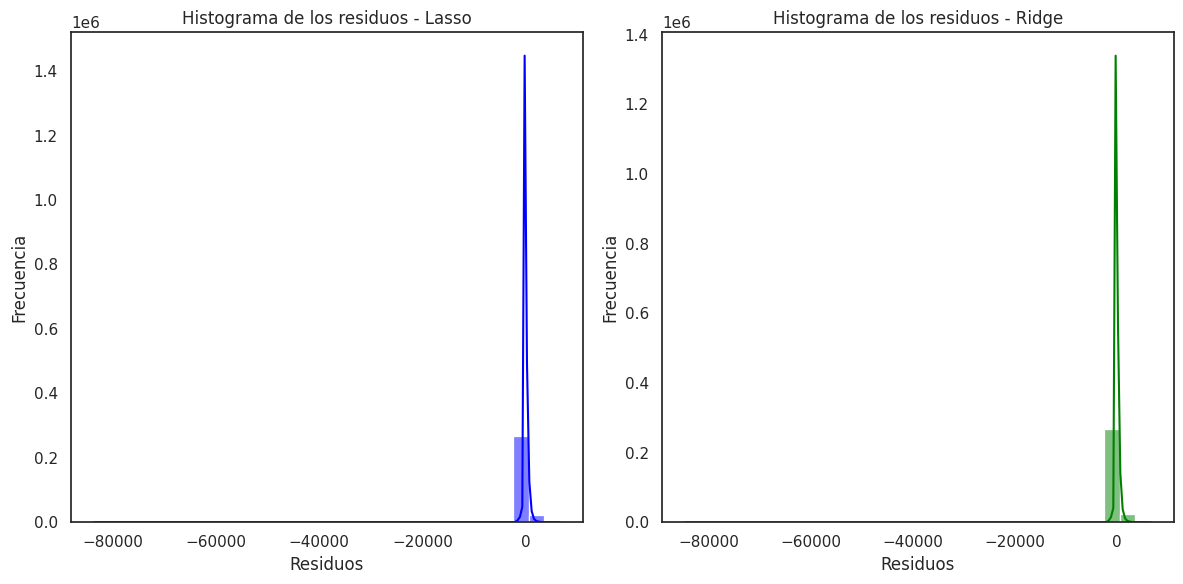

In [87]:
from sklearn.linear_model import Lasso, Ridge

# Calcular los residuos de los modelos Lasso y Ridge
residuos_lasso = y_test - y_pred_lasso
residuos_ridge = y_test - y_pred_ridge

# Graficar el histograma de los residuos de Lasso
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuos_lasso, bins=30, kde=True, color='blue')
plt.title('Histograma de los residuos - Lasso')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Graficar el histograma de los residuos de Ridge
plt.subplot(1, 2, 2)
sns.histplot(residuos_ridge, bins=30, kde=True, color='green')
plt.title('Histograma de los residuos - Ridge')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()



El puntaje de score para este modelo de regresión lineal no es mejor y tampoco el que deseamos y el modelo podría no estar capturando correctamente la relación entre las variables predictoras y la variable objetivo.

El modelo puede estar haciendo predicciones sistemáticas que no están bien balanceadas alrededor del valor real.

SAGA (Stochastic Average Gradient Descent):

* Es un método de optimización basado en gradiente estocástico (SGD), pero con memoria de gradientes pasados, lo que lo hace más eficiente.

* Funciona bien en datasets grandes y dispersos (sparse data), como en modelos con muchas características pero pocos valores diferentes.

* A diferencia de SGD puro, SAGA tiene una mejor convergencia y reduce la varianza del gradiente, lo que mejora estabilidad y precisión.

In [88]:
ridge_reg = Ridge(alpha=1.0, solver='saga').fit(X_train, y_train)

# Hacer predicciones
y_pred_ridge = ridge_reg.predict(X_test)

# Puntajes de entrenamiento y prueba
train_score = ridge_reg.score(X_train, y_train)
test_score = ridge_reg.score(X_test, y_test)

# Mostrar los resultados
print(f"Training set score: {train_score:.2f}")
print(f"Test set score: {test_score:.2f}")


Training set score: 0.61
Test set score: 0.54


In [89]:
# Medir tiempo para Lasso
start_time = time.time()
lasso_reg = Lasso(alpha=0.1).fit(X_train, y_train)
lasso_time = time.time() - start_time

# Hacer predicciones
y_pred_lasso = lasso_reg.predict(X_test)

# Calcular los residuos
residuos_lasso = y_test - y_pred_lasso

# Puntajes de entrenamiento y prueba
train_score = lasso_reg.score(X_train, y_train)
test_score = lasso_reg.score(X_test, y_test)

# Mostrar los resultados
print(f"Training set score: {train_score:.2f}")
print(f"Test set score: {test_score:.2f}")
print(f"Tiempo de entrenamiento Lasso: {lasso_time:.4f} segundos")


Training set score: 0.61
Test set score: 0.54
Tiempo de entrenamiento Lasso: 0.1260 segundos


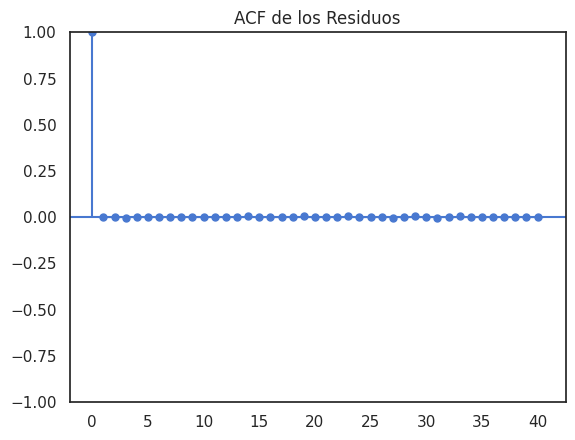

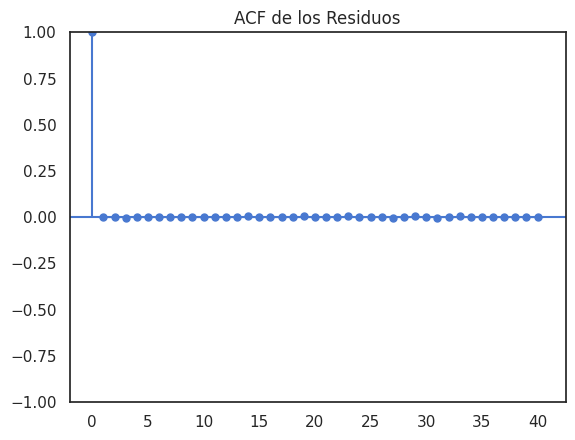

In [90]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_lasso, lags=40)
plt.title('ACF de los Residuos')
plt.show()
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_ridge, lags=40)
plt.title('ACF de los Residuos')
plt.show()

Si hay menos costo computacional al agregar saga en los modelos de regresión.

#Random forest regressor
Random Forest es un algoritmo de aprendizaje automático basado en árboles de decisión. Consiste en construir múltiples árboles de decisión durante el entrenamiento y luego combinar sus resultados para obtener una predicción más precisa y robusta.

In [91]:
from sklearn.ensemble import RandomForestRegressor

# Creamos el modelo de regresión Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# Puntajes de entrenamiento y prueba
print("Training set score: {:.2f}".format(rf_reg.score(X_train, y_train)))
print("Test set score: {:.2f}".format(rf_reg.score(X_test, y_test)))

Training set score: 0.97
Test set score: 0.76


El modelo de Random Forest tiene un puntaje bastante alto en ambos conjuntos, lo que sugiere que ha aprendido de manera efectiva de los datos de entrenamiento y puede hacer predicciones razonablemente precisas sobre nuevos datos (test set).

In [92]:
from statsmodels.tsa.stattools import acf
import time

# Hacer predicciones con el modelo de Random Forest
y_pred_rf = rf_reg.predict(X_test)

# Calcular residuos
residuos_rf = y_test - y_pred_rf

# Calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

# Calcular RMSE (Root Mean Squared Error)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# Calcular R²
r2_rf = r2_score(y_test, y_pred_rf)
# Realizar el test de Ljung-Box (autocorrelación de residuos)
acf_values, ljungbox_stat, ljungbox_p_value = acf(residuos_rf, nlags=10, qstat=True)

# Mostrar los resultados
print(f"MAPE: {mape_rf:.4f}%")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")
print(f"Ljung-Box p-value (lag=10): {ljungbox_p_value[0]:.4f}")



MAPE: 40.3538%
RMSE: 323.3614
R²: 0.7564
Ljung-Box p-value (lag=10): 0.3543


In [93]:
from scipy.stats import jarque_bera

# Realizar el test de Jarque-Bera
jb_stat, jb_p_value = jarque_bera(residuos_rf)

# Mostrar los resultados
print(f"Estadístico de Jarque-Bera: {jb_stat:.4f}")
print(f"P-valor del test de Jarque-Bera: {jb_p_value:.4f}")




Estadístico de Jarque-Bera: 4856381.7609
P-valor del test de Jarque-Bera: 0.0000


El modelo tiene un buen rendimiento, con un R² de 0.75 que indica que es capaz de explicar una buena parte de la variabilidad en los datos. Sin embargo, el MAPE y el RMSE indican que hay un margen de mejora, ya que el modelo tiene un error considerable en las predicciones.

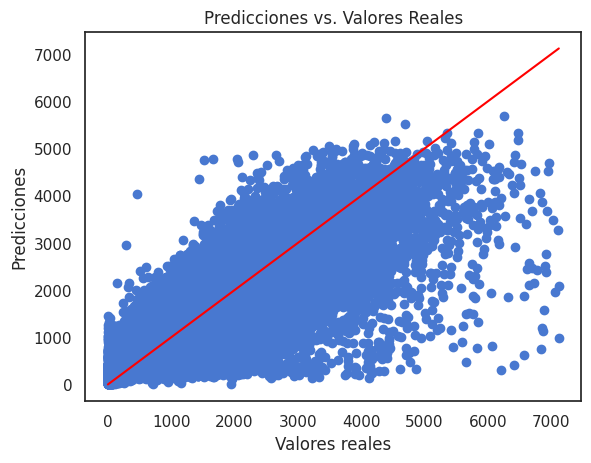

In [122]:
plt.scatter(y_test, y_pred_rf)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Línea diagonal
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales')
plt.show()

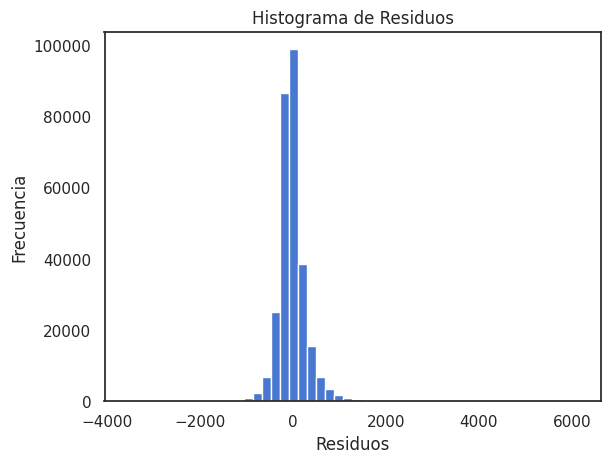

In [95]:
plt.hist(residuos_rf, bins=50)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()


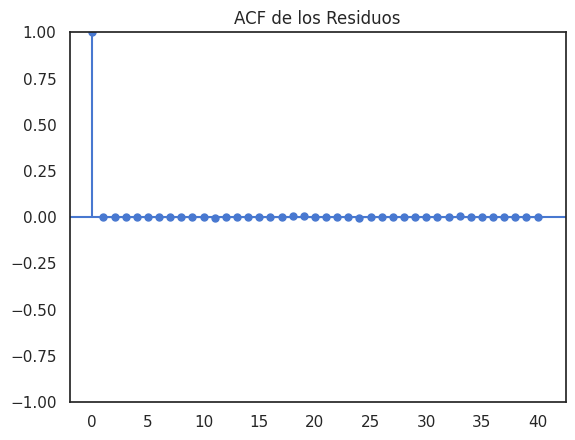

In [96]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_rf, lags=40)
plt.title('ACF de los Residuos')
plt.show()


##XG Boost regressor
XGBoost (Extreme Gradient Boosting) es un algoritmo de machine learning basado en la técnica de boosting, específicamente diseñado para mejorar el rendimiento y la eficiencia en la predicción de modelos. Es una versión optimizada de Gradient Boosting, que crea un conjunto de modelos débiles (por lo general, árboles de decisión) de manera secuencial, donde cada modelo sucesivo corrige los errores del anterior. XGBoost es conocido por su alta precisión, velocidad y capacidad para manejar grandes volúmenes de datos y características complejas.

In [97]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Crear el modelo XGBoost Regressor
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1, max_depth = 5, alpha = 10, n_estimators = 100)
# Entrenar el modelo
xgb_reg.fit(X_train, y_train)
# Hacer predicciones
y_pred_xgb = xgb_reg.predict(X_test)

# Puntajes de entrenamiento y prueba
print("Training set score: {:.2f}".format(xgb_reg.score(X_train, y_train)))
print("Test set score: {:.2f}".format(xgb_reg.score(X_test, y_test)))

Training set score: 0.65
Test set score: 0.65


Ambos puntajes son bastante similares, lo que indica que el modelo no está sobreajustado (overfitting) ni subajustado (underfitting). Es decir, el modelo está generalizando bien a los datos de prueba.

Aplicando (tree_method='hist' y early_stopping_rounds)

In [98]:
# Crear el modelo XGBoost con tree_method='hist'
model_xgb_hist = xgb.XGBRegressor(
    n_estimators=1000,
    tree_method='hist',
    random_state=42,
    learning_rate=0.1,
    max_depth=6
)

# Entrenar el modelo
model_xgb_hist.fit(X_train, y_train)
# Hacer predicciones
y_pred_xgb_hist = model_xgb_hist.predict(X_test)
# Evaluar el modelo
mae_xgb_hist = mean_absolute_error(y_test, y_pred_xgb_hist)
rmse_xgb_hist = np.sqrt(mean_squared_error(y_test, y_pred_xgb_hist))
r2_xgb_hist = r2_score(y_test, y_pred_xgb_hist)

# Mostrar los resultados
print(f"Training set score: {model_xgb_hist.score(X_train, y_train):.2f}")
print(f"Test set score: {model_xgb_hist.score(X_test, y_test):.2f}")
print(f"MAE: {mae_xgb_hist:.4f}")
print(f"RMSE: {rmse_xgb_hist:.4f}")
print(f"R²: {r2_xgb_hist:.4f}")


Training set score: 0.78
Test set score: 0.77
MAE: 203.5101
RMSE: 315.4728
R²: 0.7682


En general, el modelo XGBoost con tree_method='hist' y early stopping mostró un buen desempeño, con un alto R² y una baja desviación en los errores, indicando que es capaz de hacer predicciones precisas. Sin embargo, aún hay espacio para mejorar, lo que podría implicar ajustar más los hiperparámetros o explorar nuevas características.

In [99]:
import time

# Iniciar temporizador
start_time_initial = time.time()
#modelo XGBoost
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1, max_depth = 5, alpha = 10, n_estimators = 100)

xgb_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_xgb = xgb_reg.predict(X_test)

# Calcular el tiempo transcurrido
end_time_initial = time.time()
cpu_time_initial = end_time_initial - start_time_initial

# Mostrar el tiempo de entrenamiento
print(f"Tiempo de entrenamiento del modelo inicial (sin optimización): {cpu_time_initial:.4f} segundos")


Tiempo de entrenamiento del modelo inicial (sin optimización): 1.4440 segundos


In [100]:
# Iniciar temporizador
start_time_optimized = time.time()

# Crear el modelo XGBoost con tree_method='hist'
model_xgb_hist = xgb.XGBRegressor(
    n_estimators=1000,
    tree_method='hist',
    random_state=42,
    learning_rate=0.1,
    max_depth=6
)

# Entrenar el modelo
model_xgb_hist.fit(X_train, y_train)

# Hacer predicciones
y_pred_xgb_hist = model_xgb_hist.predict(X_test)

# Calcular el tiempo transcurrido
end_time_optimized = time.time()
cpu_time_optimized = end_time_optimized - start_time_optimized

# Mostrar el tiempo de entrenamiento
print(f"Tiempo de entrenamiento del modelo optimizado (con tree_method='hist'): {cpu_time_optimized:.4f} segundos")


Tiempo de entrenamiento del modelo optimizado (con tree_method='hist'): 12.6896 segundos


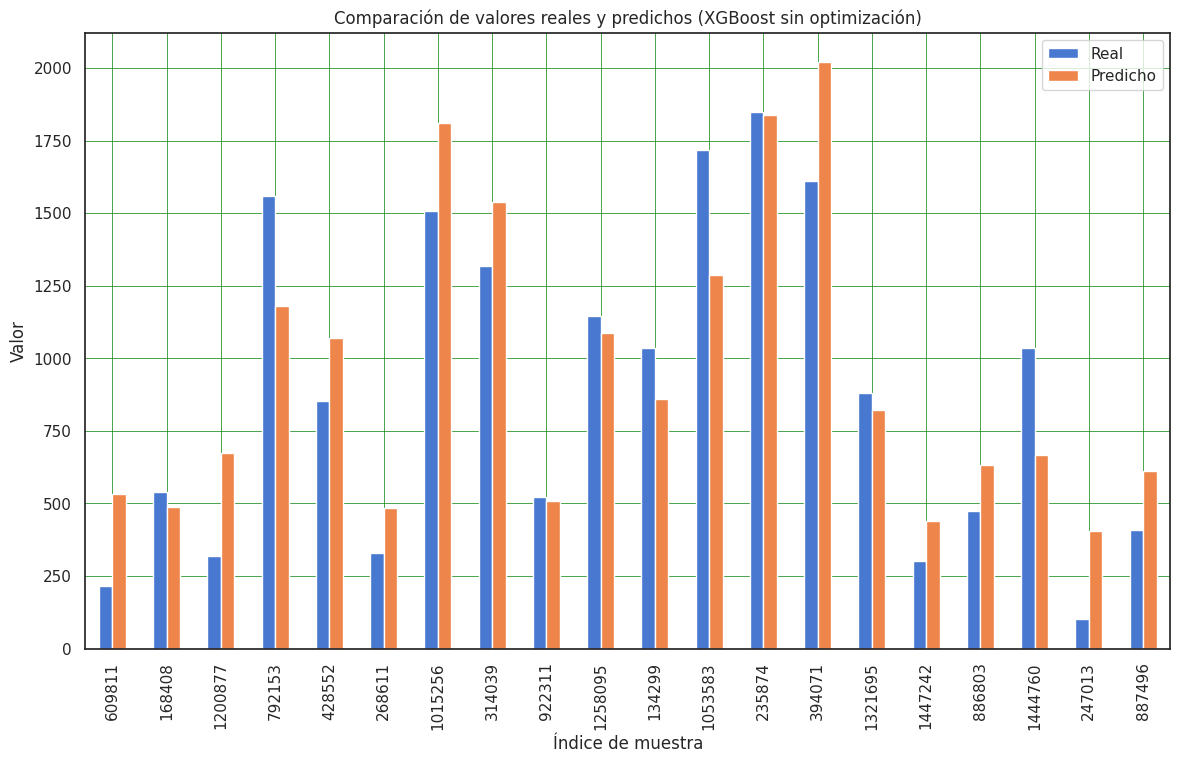

In [101]:
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3,
                           learning_rate = 0.1, max_depth = 5, alpha = 10, n_estimators = 100)

xgb_reg.fit(X_train, y_train)

y_pred_xgb = xgb_reg.predict(X_test)

# Crear un DataFrame con valores reales y predichos
df_comparacion = pd.DataFrame({'Real': y_test, 'Predicho': y_pred_xgb})

# Tomar una muestra de 20 valores aleatorios
df_muestra = df_comparacion.sample(20, random_state=42)

# Crear el gráfico de barras
df_muestra.plot(kind='bar', figsize=(14, 8))

# Personalizar el gráfico
plt.title('Comparación de valores reales y predichos (XGBoost sin optimización)')
plt.xlabel('Índice de muestra')
plt.ylabel('Valor')
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.legend()
plt.show()

Tomando una muestra aleatoria de 20 datos podemos observar la presición de los datos predichos con los reales y la capacidad que tiene el modelo y las mejoras que puede tener.

In [102]:
# Calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    mask = np.abs(y_true) > 1e-10
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

residuos_xgb = y_test - y_pred_xgb
ljungbox_test = acorr_ljungbox(residuos_xgb, lags=[10])

if isinstance(ljungbox_test, tuple):
    ljungbox_p_value = ljungbox_test[1][0]
else:
    ljungbox_p_value = ljungbox_test['lb_pvalue'].values[0]

jb_stat, jb_p_value = stats.jarque_bera(residuos_xgb)

# Mostrar los resultados
print(f"Training set score: {xgb_reg.score(X_train, y_train):.2f}")
print(f"Test set score: {xgb_reg.score(X_test, y_test):.2f}")
print(f"MAPE: {mape_xgb:.4f}%")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²: {r2_xgb:.4f}")
print(f"Ljung-Box p-value (lag=10): {ljungbox_p_value:.4f}")
print(f"Jarque-Bera p-value: {jb_p_value:.4f}")


Training set score: 0.65
Test set score: 0.65
MAPE: 58.4439%
RMSE: 386.1021
R²: 0.6528
Ljung-Box p-value (lag=10): 0.7844
Jarque-Bera p-value: 0.0000


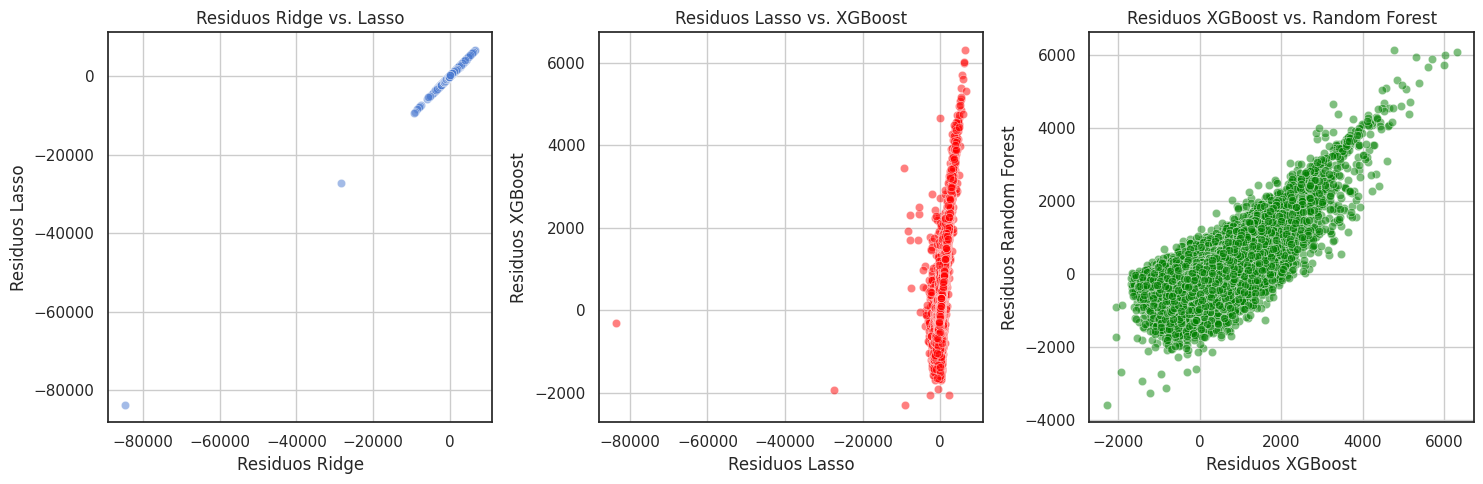

In [123]:
import seaborn as sns

# Crear una figura con subgráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot Ridge vs. Lasso
sns.scatterplot(x=residuos_ridge, y=residuos_lasso, ax=axes[0], alpha=0.5)
axes[0].set_title("Residuos Ridge vs. Lasso")
axes[0].set_xlabel("Residuos Ridge")
axes[0].set_ylabel("Residuos Lasso")
axes[0].grid()

# Scatter plot Lasso vs. XGBoost
sns.scatterplot(x=residuos_lasso, y=residuos_xgb, ax=axes[1], alpha=0.5, color="red")
axes[1].set_title("Residuos Lasso vs. XGBoost")
axes[1].set_xlabel("Residuos Lasso")
axes[1].set_ylabel("Residuos XGBoost")
axes[1].grid()

# Scatter plot XGBoost vs. Random Forest
sns.scatterplot(x=residuos_xgb, y=residuos_rf, ax=axes[2], alpha=0.5, color="green")
axes[2].set_title("Residuos XGBoost vs. Random Forest")
axes[2].set_xlabel("Residuos XGBoost")
axes[2].set_ylabel("Residuos Random Forest")
axes[2].grid()

plt.tight_layout()
plt.show()



En las gráficas anteriores visualizamos la dispersión de los residuos entre algunos de los modeloes que llevamos hasta ahora, los de regresión los residuos son muy parecidos y con los demás modelos podemos observar que se generan residuos distintos.

##SVR

SVM funciona correlacionando datos a un espacio de características de grandes dimensiones de forma que los puntos de datos se puedan categorizar, incluso si los datos no se puedan separar linealmente de otro modo. Se detecta un separador entre las categorías y los datos se transforman de forma que el separador se puede extraer como un hiperplano. Tras ello, las características de los nuevos datos se pueden utilizar para predecir el grupo al que pertenece el nuevo registro.

In [104]:
from sklearn.linear_model import SGDRegressor
from sklearn.svm import LinearSVR
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# 1. Linear SVM (LinearSVR)
linear_svm = LinearSVR(C=1.0, max_iter=1000)
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

# 2. RBF SVM con Random Fourier Features
rbf_feature = RBFSampler(gamma=1.0, random_state=42, n_components=100)
rbf_svm = make_pipeline(rbf_feature, SGDRegressor(max_iter=1000, tol=1e-3))
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)

# Evaluación de modelos
def evaluar_modelo(nombre, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Resultados del modelo {nombre}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}\n")

# Mostrar resultados

evaluar_modelo("Linear SVM", y_test, y_pred_linear)
evaluar_modelo("RBF SVM con Random Fourier Features", y_test, y_pred_rbf)




/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Resultados del modelo Linear SVM:
  MAE: 276.0756
  RMSE: 451.8903
  R²: 0.5244

Resultados del modelo RBF SVM con Random Fourier Features:
  MAE: 421.3994
  RMSE: 614.4309
  R²: 0.1206



In [112]:
mape_svm = np.mean(np.abs((y_test - y_pred_linear) / y_test)) * 100
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_svm = r2_score(y_test, y_pred_linear)
#Atocorrelacion
ljungbox_results = acorr_ljungbox(y_test - y_pred_linear, lags=[10], return_df=True)
#Normalidad
jb_stat, jb_p_value = stats.jarque_bera(y_test - y_pred_linear)

# Mostrar resultados
print(f"Resultados del modelo Linear SVM:")
print(f"  MAPE: {mape_svm:.4f}%")
print(f"  RMSE: {rmse_svm:.4f}")
print(f"  R²: {r2_svm:.4f}")
print(f"  Ljung-Box p-value: {ljungbox_results['lb_pvalue'].values[0]:.4f}")
print(f"  Jarque-Bera p-value: {jb_p_value:.4f}")


Resultados del modelo Linear SVM:
  MAPE: 59.4821%
  RMSE: 446.5720
  R²: 0.5355
  Ljung-Box p-value: 0.6456
  Jarque-Bera p-value: 0.0000


<Figure size 800x400 with 0 Axes>

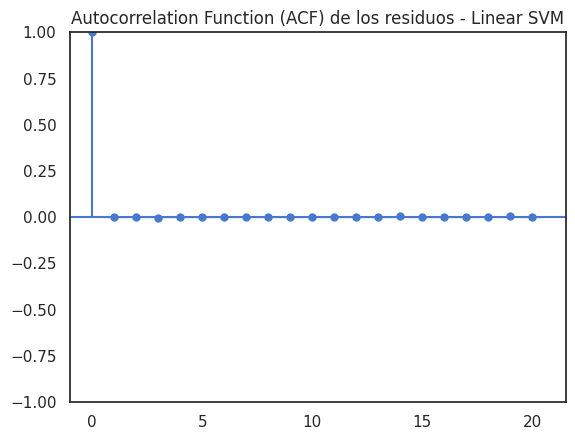

In [113]:
# Calcular residuos
residuos = y_test - y_pred_linear

# Gráfico de ACF de los residuos
plt.figure(figsize=(8, 4))
sm.graphics.tsa.plot_acf(residuos, lags=20)
plt.title("Autocorrelation Function (ACF) de los residuos - Linear SVM")
plt.show()

El modelo no presenta autocorrelación en los residuos.

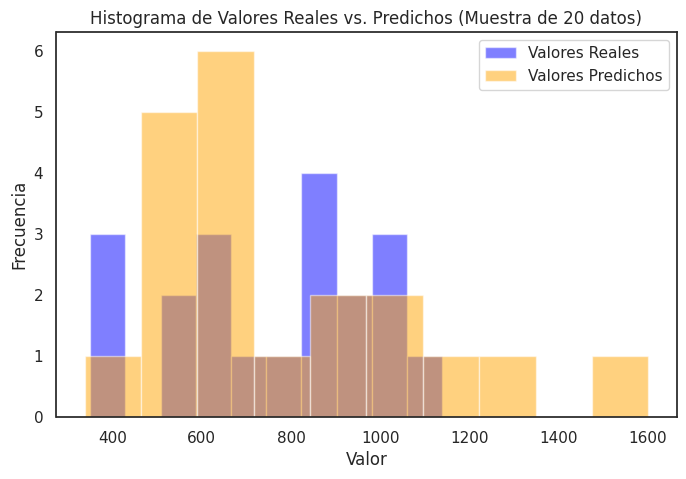

In [116]:
# Seleccionar una muestra aleatoria de 20 índices
import random
random.seed(42)
indices_muestra = random.sample(range(len(y_test)), 20)

# Extraer los valores de la muestra
y_real_muestra = np.array(y_test)[indices_muestra]
y_pred_muestra = np.array(y_pred_linear)[indices_muestra]

plt.figure(figsize=(8, 5))
plt.hist(y_real_muestra, bins=10, alpha=0.5, label='Valores Reales', color='blue')
plt.hist(y_pred_muestra, bins=10, alpha=0.5, label='Valores Predichos', color='orange')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Histograma de Valores Reales vs. Predichos (Muestra de 20 datos)')
plt.legend()
plt.show()

La gráfica muestra que el modelo Linear SVM no captura bien la variabilidad de los datos reales, ya que sus predicciones están más concentradas en ciertos rangos y no reflejan completamente la distribución real. Esto sugiere que el modelo puede estar subestimando o sobreestimando algunos valores, lo que afecta su precisión.

##Tabla comparativa de los modelos implemtados:

Estaremos observando la tabla comparativa de los modelos implementados anteriormente según las métricas requeridas.

In [118]:
import pandas as pd

# Crear diccionario con los datos
data = {
    "Model": ["KNN", "Linear Regression", "Ridge Regression", "Lasso Regression",
              "Random Forest", "XGBoost", "SVR"],
    "MAPE": [45.7613, 59.4820, 59.4820, 59.3872, 40.3538, 58.4439, 59.4821],
    "RMSE": [346.2232, 446.5720, 446.5706, 445.4155, 323.3614, 386.1021, 446.5720],
    "R²": [0.7208, 0.5355, 0.5355, 0.5379, 0.7564, 0.6528, 0.5355],
    "Ljung-Box p-value": [0.6971, 0.6456, 0.6456, 0.6516, 0.3543, 0.7844, 0.6456],
    "Jarque-Bera p-value": [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
}

# Crear el DataFrame
df_results = pd.DataFrame(data)




In [119]:
from IPython.display import display
display(df_results)


,Model,MAPE,RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,KNN,45.7613,346.2232,0.7208,0.6971,0.0
1,Linear Regression,59.4820,446.5720,0.5355,0.6456,0.0
2,Ridge Regression,59.4820,446.5706,0.5355,0.6456,0.0
3,Lasso Regression,59.3872,445.4155,0.5379,0.6516,0.0
4,Random Forest,40.3538,323.3614,0.7564,0.3543,0.0
5,XGBoost,58.4439,386.1021,0.6528,0.7844,0.0
6,SVR,59.4821,446.5720,0.5355,0.6456,0.0


El modelo con mejor desempeño es Random Forest, ya que presenta el menor error (MAPE: 40.35%, RMSE: 323.36) y el mayor R² (0.7564), seguido por XGBoost, que también obtiene buenos resultados. En contraste, los modelos lineales (Regresión Lineal, Ridge y Lasso) y SVR muestran los peores valores de error y explican menos la variabilidad de los datos (R² ≈ 0.5355).

La prueba de Ljung-Box indica que no hay autocorrelación significativa en los residuos, pero la prueba de Jarque-Bera sugiere que en todos los modelos los residuos no siguen una distribución normal.